In [27]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyranges as pr
import glob as glob
import os
from importlib import reload
%matplotlib inline
import sys
sys.path.append("modules")
import bedgraph_tools as bgt
import peak_tools as pkt
from collections import defaultdict
import pyBigWig as pw
import pysam
from itertools import groupby
from Bio import motifs
import logomaker
from Bio import Align
from Bio.Seq import Seq
%config InlineBackend.figure_format='retina'
import matplotlib
from scipy import stats
from scipy.interpolate import interp1d
matplotlib.rcParams['pdf.fonttype'] = 42
nmeta = pd.read_parquet('metadata/metadata.parquet')
import matplotlib.colors as mcolors
import upsetplot
from scipy.ndimage import uniform_filter


In [2]:
metadata = pd.read_parquet('metadata/metadata.parquet')

In [3]:
def load_and_rename_mot(path, name):
    mot_enrich = pd.DataFrame(pd.read_csv(os.path.join(path, 'fimo.tsv'), delimiter='\t').iloc[:-3].set_index('sequence_name').loc[:, 'score']).reset_index().groupby('sequence_name').count()
    mot_enrich.columns = [name]
    return mot_enrich

def average_bgs(path_list, ):
    con = pl.concat([pl.read_parquet(x) for x in path_list])\
    .group_by(['Chromosome', 'Start', 'End']).sum()\
    .with_columns((pl.col('Normalized_Reads')/len(path_list)).alias('mean_norm_reads'),
                  (pl.col('Name')/len(path_list)).alias('mean_raw_reads'),
                  pl.col('Chromosome').cast(str))\
    .sort(by=['Chromosome', 'Start'])

    return con


def process_window_peaks(n_peaks: pd.DataFrame, avbgs: pl.DataFrame, window: int = 1000, mid_col: str = 'Middle', strand_col: str = 'Strand'):
    """
    Process windowed peak regions and extract normalized read values.

    Parameters:
        n_peaks (pd.DataFrame): DataFrame containing peaks with columns ['Chromosome', 'middle', 'strand'].
        avbgs (pl.DataFrame): Polars DataFrame with columns ['Chromosome', 'Start', 'End', 'mean_norm_reads'].
        window (int): Window size around the mid_motif_peak (default is 200).

    Returns:
        list: List of normalized read arrays, adjusted for strand orientation.
    """
    signals = []

    for chrom, mid, strand in n_peaks[['Chromosome', mid_col, strand_col]].values:
        a = np.zeros(window)

        coords = avbgs.filter(
            (pl.col('Chromosome') == chrom) &
            (pl.col('Start') >= (int(mid) - (window / 2))) &
            (pl.col('End') <= (int(mid) + (window / 2)))
        ).select(['Start', 'mean_norm_reads']) \
         .with_columns(pl.col('Start') - (int(mid) - (window / 2))) \
         .sort(['Start']) \
         .to_numpy()

        a[coords[:, 0].astype(int)] = coords[:, 1]

        signals.append(a if strand == '+' else a[::-1])

    return signals

def prep_peak_fimos(key, fam, metadata):
    gr = metadata.loc[key]
    peak = gr.iloc[-1]
    peak = pr.read_bed(peak).df
    
    gr_wt_lig_fimod = pivoted.filter(regex=fam).filter(regex=key+"$", axis=0)
    loaded_fimos = {key:pr.PyRanges(pr.read_gff3(os.path.join(value, 'fimo.gff')).df.loc[:, ['Chromosome', 'Start', 'End']]) for key, value in gr_wt_lig_fimod.T.squeeze().to_dict().items()}
    
    return gr, peak, loaded_fimos
def plot_coccurrent_motifs(peak, loaded_fimos):
    range_peaks = pr.PyRanges(peak.loc[:, ['Chromosome', 'Start', 'End']])
    conc_fimo_peaks = lambda x: range_peaks.join(loaded_fimos[x], how='left', suffix='_'+x.split('_')[1]).cluster().df.groupby("Cluster").agg(lambda x: list(x)[0]).iloc[:, -1:]
    mot_occurences = (pd.concat(map(conc_fimo_peaks, list(loaded_fimos.keys())), axis=1)>0)*1
    mot_occ_df = pd.concat([range_peaks.df, mot_occurences.reset_index()], axis=1).drop("Cluster", axis=1)

    total_overlaps = pd.DataFrame(mot_occ_df.filter(regex='End_').sum(axis=1)).groupby(0).size()
    total_overlaps_frac = (total_overlaps / total_overlaps.sum()) *100
    fig, ax = plt.subplots(1)
    ax.bar(total_overlaps.index, total_overlaps, ec='k', lw=.5, width=1)
    for key, value in total_overlaps.to_dict().items():
        ax.text(key-.25, value+25, np.round(total_overlaps_frac.loc[key], 2))

    ax.set_xlabel('Number of cooccurent motif types')
    ax.set_ylabel('Number of peaks')
    return fig
def calculate_motif_distances(ogfimo, self_motif_name, loaded_fimos, peak, slack=500):
    nr_range = pr.PyRanges(pr.read_gff3(ogfimo).df.loc[:, ["Chromosome", 'Start', 'End']])

    for name,i in loaded_fimos.items():
        if name == self_motif_name:
            continue
        nr_range = nr_range.join(i, slack=500, how='outer', suffix="_" + name.split('_')[1])
    nr_range = nr_range.df

    # If you want to use the motif strands, you will need to find them from here
    nr_range = nr_range.loc[:, ['Chromosome', 'Start', 'End', 'Start_AP1',
           'End_AP1', 'Start_FOX','End_FOX' ,'Start_TEAD',
           'End_TEAD', 'Start_KLF', 'End_KLF', 'Start_RUNX',
           'End_RUNX', 'Start_halfsite', 'End_halfsite', 'Start_CTCF', 'End_CTCF']]
    nr_range = nr_range.replace(-1, np.nan)
    nr_range.columns = ['Chromosome', 'Start_NR', 'End_NR', 'Start_AP1', 'End_AP1', 'Start_FOX',
           'End_FOX', 'Start_TEAD', 'End_TEAD', 'Start_KLF', 'End_KLF',
           'Start_RUNX', 'End_RUNX', 'Start_halfsite', 'End_halfsite', 'Start_CTCF', 'End_CTCF']
    for i in ['NR', 'AP1', 'FOX', 'TEAD', 'KLF', 'RUNX', 'halfsite', 'CTCF']:
        cd = nr_range.loc[:, [f'Start_{i}', f'End_{i}']]
        mid = cd.iloc[:, 0] + np.ceil(((cd.iloc[:, 1] - cd.iloc[:, 0])/2))
        nr_range.loc[:, f'{i}_Mid'] = mid.values


    mid_motifs = nr_range.loc[:, ['Chromosome', 'NR_Mid', 'AP1_Mid', 'FOX_Mid', 'TEAD_Mid', 'KLF_Mid', 'RUNX_Mid', 'halfsite_Mid', 'CTCF_Mid']]

    for mid in ['NR_Mid', 'AP1_Mid', 'FOX_Mid', 'TEAD_Mid', 'KLF_Mid', 'RUNX_Mid', 'halfsite_Mid', 'CTCF_Mid']:
        distances = nr_range.filter(regex='Mid').apply(lambda x: x - nr_range.loc[:, mid]).drop(mid, axis=1)
        distances.columns = ["{}_minus_{}".format(x.replace("_Mid", ''), mid.replace('_Mid', '')) for x in distances.columns]
        mid_motifs = pd.concat([mid_motifs, distances], axis=1)
    mid_motifs.loc[:, 'dummy_strand'] = '+'
    coocc = (mid_motifs.filter(regex='Mid')>0) * 1
    coocc.columns = [x.replace("_Mid", '_Occ') for x in coocc.columns]
    mid_motifs.loc[:, 'unique'] = np.nan


    for col in coocc.columns:
        cun = (coocc[coocc[col]==1].drop(col, axis=1).sum(axis=1)==0)
        mid_motifs.loc[cun[cun].index, 'unique'] = col.replace('_Occ', '')

    main_peaks_pyrange = pr.PyRanges(peak.loc[:, ['Chromosome', 'Start', 'End']])
    npeaks = main_peaks_pyrange.df.shape[0]
    
    return mid_motifs, npeaks, main_peaks_pyrange




    

    
def extract_signals_with_dists(nr_comps, avebw, mlist, main_peaks_pyrange):
    means_dist = defaultdict(dict)
    fps = dict()
    for i in mlist:
        print(i)
        trial = nr_comps.filter(regex=f'Mid|{i}|Chrom').dropna()
        trial.loc[:, 'Strand'] = trial.iloc[:, -1].apply(lambda x: '+' if x>0 else '-')
        trial.index = trial.iloc[:,0].astype(str) + ':' + trial.iloc[:,1].astype(str)+ ':' + trial.iloc[:,2].astype(str)
        trial = trial[~trial.index.duplicated()]
        trial = trial.loc[np.abs(trial.iloc[:,2]).sort_values(ascending=True).index]


        for_pyrange = trial.copy().iloc[:, [0,1,-1]]
        for_pyrange.columns = ['Chromosome', 'Start', 'Strand']
        for_pyrange.loc[:, 'End'] = for_pyrange.Start+1
        npyrange = pr.PyRanges(for_pyrange)
        overlappedp = main_peaks_pyrange.join(npyrange).cluster().df.Cluster.max()
        sigs = process_window_peaks(trial,avebw , 1000, trial.columns[1],)
        df = pd.DataFrame(sigs)

        df.loc[:, 'absdist'] = np.abs(trial.iloc[:, -2].values)
        fps[i] = df

        num_thresh = 50
        if df.query("absdist<=100").shape[0]>num_thresh:
            means_dist[i]['l100'] = df.query("absdist<=100").iloc[:, :-1].mean()
        else:
            means_dist[i]['l100'] = np.zeros(df.query("absdist<=100").shape[1])

        if df.query("absdist>100 & absdist<=200").shape[0]>num_thresh:
            means_dist[i]['100_200'] = df.query("absdist>100 & absdist<=200").iloc[:, :-1].mean()
        else:
            means_dist[i]['100_200'] = np.zeros(df.query("absdist>100 & absdist<=200").shape[1])

        if df.query("absdist>200 & absdist<=300").shape[0]>num_thresh:
            means_dist[i]['200_300'] = df.query("absdist>200 & absdist<=300").iloc[:, :-1].mean()
        else:
            means_dist[i]['200_300'] = np.zeros(df.query("absdist>200 & absdist<=300").shape[1])

        if df.query("absdist>300 & absdist<=400").shape[0]>num_thresh:
            means_dist[i]['300_400'] = df.query("absdist>300 & absdist<=400").iloc[:, :-1].mean()
        else:
            means_dist[i]['300_400'] = np.zeros(df.query("absdist>300 & absdist<=400").shape[1])

        if df.query("absdist>400").shape[0]>num_thresh:
            means_dist[i]['u400'] = df.query("absdist>400").iloc[:, :-1].mean()
        else:
            means_dist[i]['u400'] = np.zeros(df.query("absdist>400").shape[1])
    return (means_dist, fps)

def plot_profiles(means_dist, fps, mlist):
    fig, ax = plt.subplots(len(mlist),5, sharey=True, sharex=True, figsize=(15,len(mlist)*3))
    rmse = defaultdict(dict)

    for i,k in enumerate(mlist):

        if len(mlist) == 1:
            axi = ax

            axi[0].set_ylabel(k)
        else:
            axi = ax[i]

            axi[0].set_ylabel(k)
        for axii, key, lines, quer in zip(axi, ['l100', '100_200', '200_300', '300_400', 'u400'],
                                    [(400,500), (300,400), (200,300), (100,200), (0, 100)],
                                   ["absdist<=100","absdist>100 & absdist<=200","absdist>200 & absdist<=300",
                                   "absdist>300 & absdist<=400","absdist>400 & absdist<475"]):
            smoothed = uniform_filter(means_dist[k][key], 20)
            proximal=smoothed[:500]
            distal = smoothed[500:][::-1]

            if  means_dist[k][key].sum() > 0:
                axii.plot(np.arange(500), proximal, label=f'Proximal to {k}', c='gray', lw=1, zorder=20)
                axii.plot(np.arange(lines[0], lines[1]), proximal[lines[0]:lines[1]], label=f'{k} distance from NR', c='darkorchid', lw=2.5, zorder=20)
                axii.plot(np.arange(500), distal,  label=f'Distal from {k}', c='k', lw=1.5, zorder=20)

                ins = axii.inset_axes([0.15,0.75,0.2,0.2])

                ins.plot(np.mean(fps[k].query(quer).apply(lambda x: x[475-x['absdist']:525-x['absdist']].values, axis=1), axis=0), c='navy', lw=.7)
                ins.set_xticklabels('')
                sns.despine(ax=ins, right=True, top=True)
                ins.set_xticks(np.arange(0,75, 25), np.arange(-25,50,25), size=5)
                ins.set_yticklabels(ins.get_yticklabels(), size=5)

                rmse[k][f'{key}_rmse'] = np.sqrt(np.mean((proximal[lines[0]:lines[1]]- distal[lines[0]:lines[1]])**2))
                # rmse[k][f'{key}_rmse'] = proximal[lines[0]:lines[1]].mean() / distal[lines[0]:lines[1]].mean()

                rmse[k][f'{key}_peak'] = distal[400:500].mean()
            if i==0 and axii == axi[0]:
                fig2, newax = plt.subplots(1,2, figsize=(6,2.5), sharey=True)
                newax[0].plot(np.arange(500), proximal, label=f'Proximal to {k}', c='darkorchid', lw=2, zorder=20)
                newax[0].plot(np.arange(500,1000), distal[::-1],  label=f'Distal from {k}', c='k', lw=2, zorder=20)
                newax[1].plot(np.arange(500), proximal, label=f'Proximal to {k}', c='darkorchid', lw=2, zorder=20)
                newax[1].plot(np.arange(500), distal,  label=f'Distal from {k}', c='k', lw=2, zorder=20)

            axii.axvspan(lines[0], lines[1], alpha=0.3, color='cadetblue')
            axii.set_title(key)

        axi[0].legend(bbox_to_anchor=[0, 1.4])
    return (rmse, fig, fig2)
    


In [4]:
t = metadata.filter(regex='nmumg', axis=0).filter(regex='ar|gr|pr', axis=0).filter(regex='lbd|dbd', axis=0).loc[:, 'peaks_w_summits']
nmumg_fimo = sorted(glob.glob('data/combined_threshed_peaks_wsummits/output_fimo_fasta_*'))
arr = np.array(list((pd.Index(nmumg_fimo).str.split('output_fimo_fasta_').str[1].str.split('_fc10_'))))

pivoted = pd.DataFrame((arr[:,0], arr[:, 1], nmumg_fimo)).T\
.pivot(index=0, columns=1, values=2)\
.rename_axis(None, axis=1)\
.rename_axis('index', axis=0)

In [5]:
nmummg_wtlig_mot_locs = pivoted
md = {'smad1':'SMAD1', 'hgr':'GR', 'mar':'AR', 'hpr':'PR', 'ar':'AR', 'pr':'PR', 'gr':'GR'}

mot_num_table = defaultdict(list)
peak_shape = dict()
for key, value in t.to_dict().items():
    print(key)
    if key == 'nmumg_smad1':
        key = 'nmumg_smad1_bmp_high'
    clocs = nmummg_wtlig_mot_locs.filter(regex=md[key.split('_')[1]]).loc[key]
    lpeak = pr.read_bed(value)
    peak_shape[key] = len(lpeak)
    clocs = clocs.fillna('data/combined_threshed_peaks_wsummits/output_fimo_fasta_nmumg_smad1_bmp_high_fc10_SMAD1_HNF_mot')
    for cmot, cloc in clocs.reset_index().values:
        loaded_loc = pr.read_gff3(cloc + '/fimo.gff')
        mot_num_table[key].append((cmot, lpeak.join(loaded_loc).cluster().Cluster.max()))
        

motn_Df = pd.DataFrame(mot_num_table).T.unstack().reset_index().drop('level_0', axis=1)
motn_Df.loc[:, 'mot_source'] = motn_Df.loc[:, 0].apply(lambda x: x[0])
motn_Df.loc[:, 'mot_len'] = motn_Df.loc[:, 0].apply(lambda x: x[1])
mot_table = motn_Df.drop(0, axis=1).pivot(index='level_1', columns='mot_source', values='mot_len')
motn_Df = pd.concat([motn_Df.set_index('level_1') , pd.DataFrame(peak_shape, index=['num_peaks']).T.loc[motn_Df.set_index('level_1').index]], axis=1).reset_index()
motn_Df.loc[:, 'type'] = motn_Df.mot_source.apply(lambda x: x.split('_')[1])


order_ar = ['nmumg_mar_dlbd', 'nmumg_ar_dlbd_dn100', 'nmumg_ar_dlbd_dn150', 'nmumg_ar_dlbd_dn200',
        'nmumg_mar_dlbd_dn300',
       'nmumg_mar_dlbd_dn350', 'nmumg_mar_dlbd_dn400', 'nmumg_mar_dlbd_dn450','nmumg_mar_dbd',]
order_pr = ['nmumg_hpr_del_lbd', 'nmumg_hpr_dlbd_dn100',
       'nmumg_hpr_dlbd_dn300', 'nmumg_hpr_dlbd_dn450', 'nmumg_hpr_dbd', ]
order_gr = ['nmumg_hgr_dlbd', 'nmumg_hgr_dlbd_dn50','nmumg_gr_dlbd_dn100', 
       'nmumg_hgr_dlbd_dn150', 'nmumg_hgr_dlbd_dn250', 'nmumg_hgr_dlbd_dn300', 'nmumg_hgr_dbd','nmumg_hgr_dlbd_dn400']


nmotsnmumg = motn_Df.\
set_index('mot_source').\
set_index('level_1').filter(regex='nmumg', axis=0)
nmotsnmumg.loc[:, 'frac'] = (nmotsnmumg.mot_len / nmotsnmumg.num_peaks).values
nmotsnmumg = nmotsnmumg.reset_index()
nmotsnmumg.loc[:, 'tf'] = nmotsnmumg.iloc[:,0].apply(lambda x: x.split('ar_')[-1])
nmotsnmumg = nmotsnmumg.set_index('level_1').loc[order_ar+order_pr+order_gr]


labels_ar = ['nmumg_mar_dlbd', 'nmumg_ar_dlbd_dn100', 'nmumg_ar_dlbd_dn150',
       'nmumg_ar_dlbd_dn200', 'nmumg_mar_dlbd_dn300', 'nmumg_mar_dlbd_dn350',
       'nmumg_mar_dlbd_dn400', 'nmumg_mar_dlbd_dn450', 'nmumg_mar_dbd']

nmumg_ar_dlbd_dn100
nmumg_ar_dlbd_dn150
nmumg_ar_dlbd_dn200
nmumg_gr_dlbd_dn100
nmumg_hgr_dbd
nmumg_hgr_dlbd
nmumg_hgr_dlbd_dn150
nmumg_hgr_dlbd_dn250
nmumg_hgr_dlbd_dn300
nmumg_hgr_dlbd_dn400
nmumg_hgr_dlbd_dn50
nmumg_hpr_dbd
nmumg_hpr_del_lbd
nmumg_hpr_dlbd_dn100
nmumg_hpr_dlbd_dn300
nmumg_hpr_dlbd_dn450
nmumg_mar_dbd
nmumg_mar_dlbd
nmumg_mar_dlbd_dn300
nmumg_mar_dlbd_dn350
nmumg_mar_dlbd_dn400
nmumg_mar_dlbd_dn450


In [6]:
hept = metadata.filter(regex='hep', axis=0).filter(regex='ar|gr|pr', axis=0).filter(regex='lbd|dbd', axis=0).loc[:, 'peaks_w_summits']

hepg2_wtlig_mot_locs = pivoted
md = {'smad1':'SMAD1', 'hgr':'GR', 'mar':'AR', 'hpr':'PR', 'ar':'AR', 'pr':'PR', 'gr':'GR'}

mot_num_table = defaultdict(list)
peak_shape = dict()
for key, value in hept.to_dict().items():
    print(key)
    if key == 'nmumg_smad1':
        key = 'nmumg_smad1_bmp_high'
    clocs = nmummg_wtlig_mot_locs.filter(regex=md[key.split('_')[1]]).loc[key]
    lpeak = pr.read_bed(value)
    peak_shape[key] = len(lpeak)
    clocs = clocs.fillna('data/combined_threshed_peaks_wsummits/output_fimo_fasta_nmumg_smad1_bmp_high_fc10_SMAD1_HNF_mot')
    for cmot, cloc in clocs.reset_index().values:
        loaded_loc = pr.read_gff3(cloc + '/fimo.gff')
        mot_num_table[key].append((cmot, lpeak.join(loaded_loc).cluster().Cluster.max()))
        
motn_Df_hep = pd.DataFrame(mot_num_table).T.unstack().reset_index().drop('level_0', axis=1)
motn_Df_hep.loc[:, 'mot_source'] = motn_Df_hep.loc[:, 0].apply(lambda x: x[0])
motn_Df_hep.loc[:, 'mot_len'] = motn_Df_hep.loc[:, 0].apply(lambda x: x[1])
mot_table = motn_Df_hep.drop(0, axis=1).pivot(index='level_1', columns='mot_source', values='mot_len')
motn_Df_hep = pd.concat([motn_Df_hep.set_index('level_1') , pd.DataFrame(peak_shape, index=['num_peaks']).T.loc[motn_Df_hep.set_index('level_1').index]], axis=1).reset_index()
motn_Df_hep.loc[:, 'type'] = motn_Df_hep.mot_source.apply(lambda x: x.split('_')[1])


nmotshep= motn_Df_hep.\
set_index('mot_source').\
set_index('level_1').filter(regex='hep', axis=0)
nmotshep.loc[:, 'frac'] = (nmotshep.mot_len / nmotshep.num_peaks).values
nmotshep = nmotshep.reset_index()
nmotshep.loc[:, 'tf'] = nmotshep.iloc[:,0].apply(lambda x: x.split('ar_')[-1])

hepg2_ar_dbd
hepg2_ar_dlbd
hepg2_gr_dbd
hepg2_gr_dlbd
hepg2_pr_dbd
hepg2_pr_dlbd


## 6A

/home/labs/barkailab/vovam/.local/lib/python3.11/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


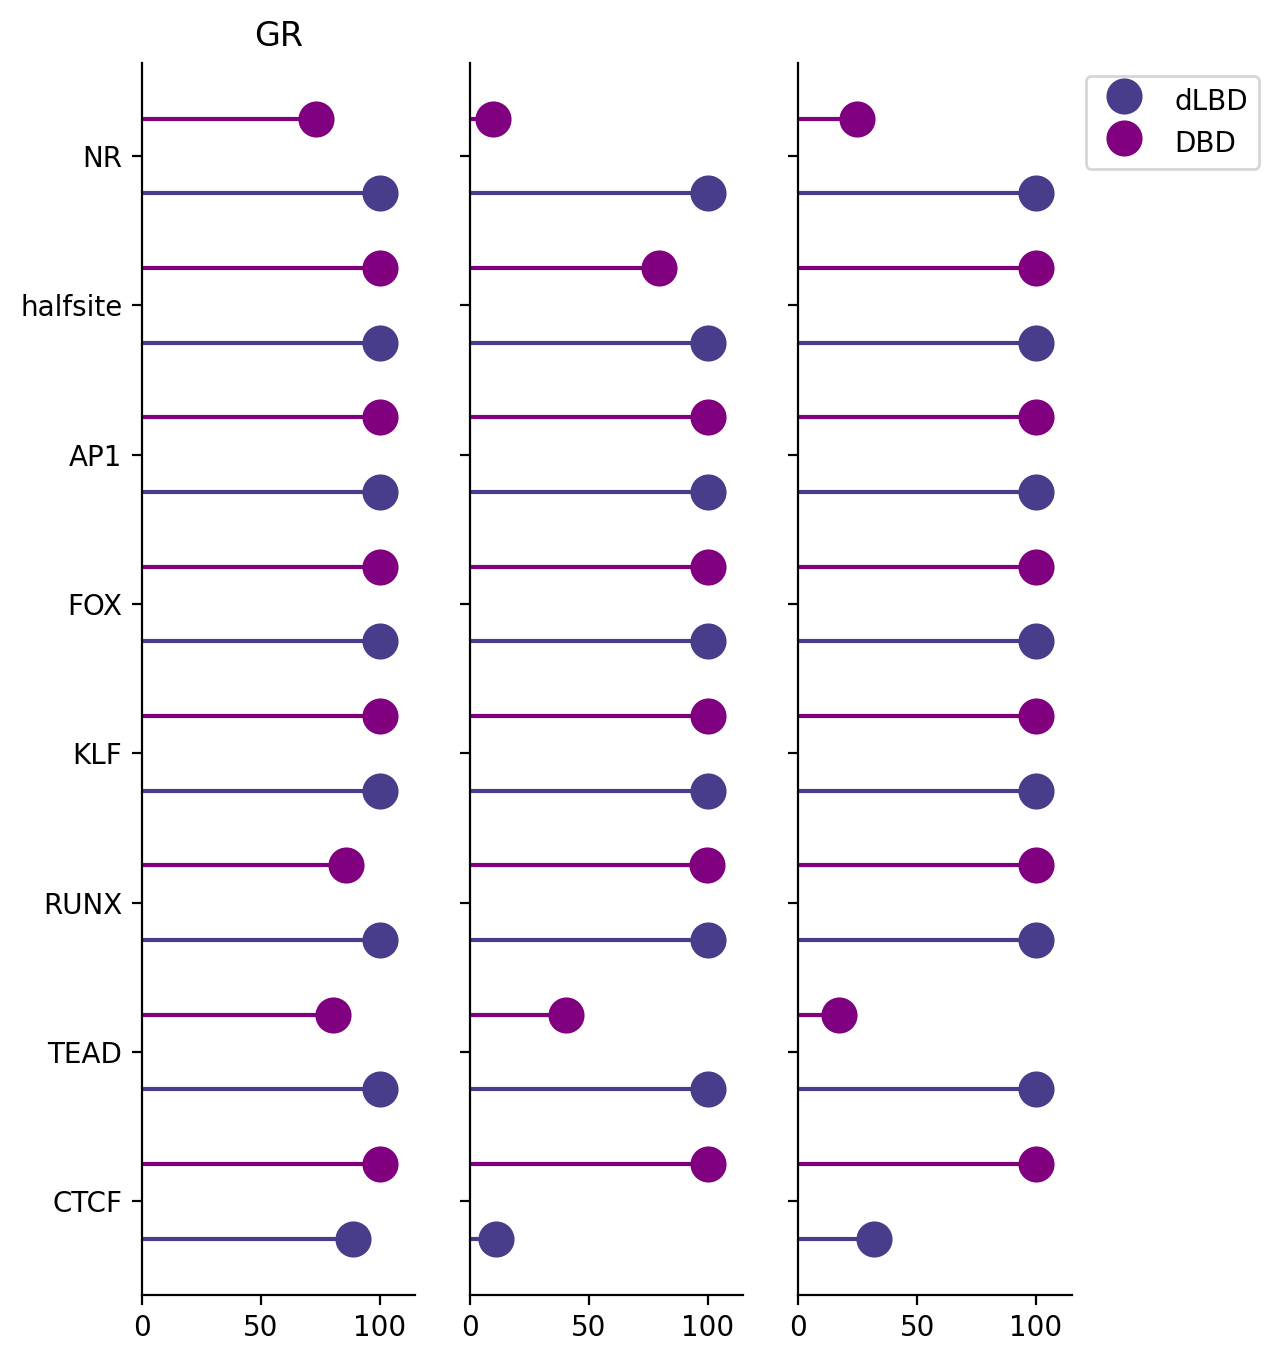

In [8]:
sea = glob.glob('data/combined_threshed_peaks_wsummits/output_sea_fasta_*')

import os
def proc(x):
    return pd.read_csv(os.path.join(x, 'sea.tsv'), delimiter='\t').iloc[:-3, ]\
    .loc[:, ['ID', 'PVALUE']]\
    .rename({'PVALUE':x.split('_fasta_')[-1].split('_fc10')[0]},axis=1)\
    .set_index('ID')


enrich_table = pd.concat([proc(x) for x in sea], axis=1)

order_ar = ['nmumg_mar_dlbd','nmumg_mar_dbd',]
order_pr = ['nmumg_hpr_del_lbd','nmumg_hpr_dbd', ]
order_gr = ['nmumg_hgr_dlbd', 'nmumg_hgr_dlbd_dn400',]

ndata = enrich_table.filter(regex='nmumg').loc[:, order_ar+order_pr+order_gr].filter(regex='KLF|AP1|NR|TEAD|FOX|RUNX|halfsite|CTCF', axis=0)
pvals = -10 * np.log10(ndata)
pvals = pvals.replace(np.inf, 4000)
pvals[pvals>100] = 100
pvals.loc[:, 'mot_type'] = ndata.reset_index().loc[:, 'ID'].apply(lambda x: x.split('_')[-1]).values
pvals = pvals.groupby('mot_type').mean()

pvals = pvals.loc[['NR', 'halfsite', 'AP1', 'FOX', 'KLF', 'RUNX', 'TEAD', 'CTCF'][::-1]].reset_index()

msize=12
fig, (ax,ax1,ax2) = plt.subplots(1,3, figsize=(6,8), sharey=True)
s = ax.stem(np.arange(8),pvals.filter(regex='ar').iloc[:, 0], orientation='horizontal', linefmt='darkslateblue', markerfmt='o', basefmt=' ')
ax.set_yticks(np.arange(pvals.shape[0])+.25, pvals.mot_type)
s.markerline.set_markersize(msize) 
s = ax.stem(np.arange(8)+.5,pvals.filter(regex='ar').iloc[:, 1], orientation='horizontal', linefmt='purple', markerfmt='o', basefmt=' ')
s.markerline.set_markersize(msize)

s = ax1.stem(np.arange(8),pvals.filter(regex='pr').iloc[:, 0], orientation='horizontal', linefmt='darkslateblue', markerfmt='o', basefmt=' ')
ax1.set_yticks(np.arange(pvals.shape[0])+.25, pvals.mot_type)
s.markerline.set_markersize(msize) 
s = ax1.stem(np.arange(8)+.5,pvals.filter(regex='pr').iloc[:, 1], orientation='horizontal', linefmt='purple', markerfmt='o', basefmt=' ')
s.markerline.set_markersize(msize)

s = ax2.stem(np.arange(8),pvals.filter(regex='gr').iloc[:, 0], orientation='horizontal', linefmt='darkslateblue', markerfmt='o', basefmt=' ', label='dLBD')
ax2.set_yticks(np.arange(pvals.shape[0])+.25, pvals.mot_type)
s.markerline.set_markersize(msize) 
s = ax2.stem(np.arange(8)+.5,pvals.filter(regex='gr').iloc[:, 1], orientation='horizontal', linefmt='purple', markerfmt='o', basefmt=' ', label='DBD')
s.markerline.set_markersize(msize)


for axi in (ax,ax1,ax2):
    sns.despine(ax=axi, right=True)
    axi.set_xlim([0,115])
ax2.legend(bbox_to_anchor=[1,1])
ax.set_title('AR')
ax.set_title('PR')
ax.set_title('GR')
fig.savefig('figures/Fig6/6A.pdf')

## 6B

/tmp/ipykernel_2178/2767386993.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


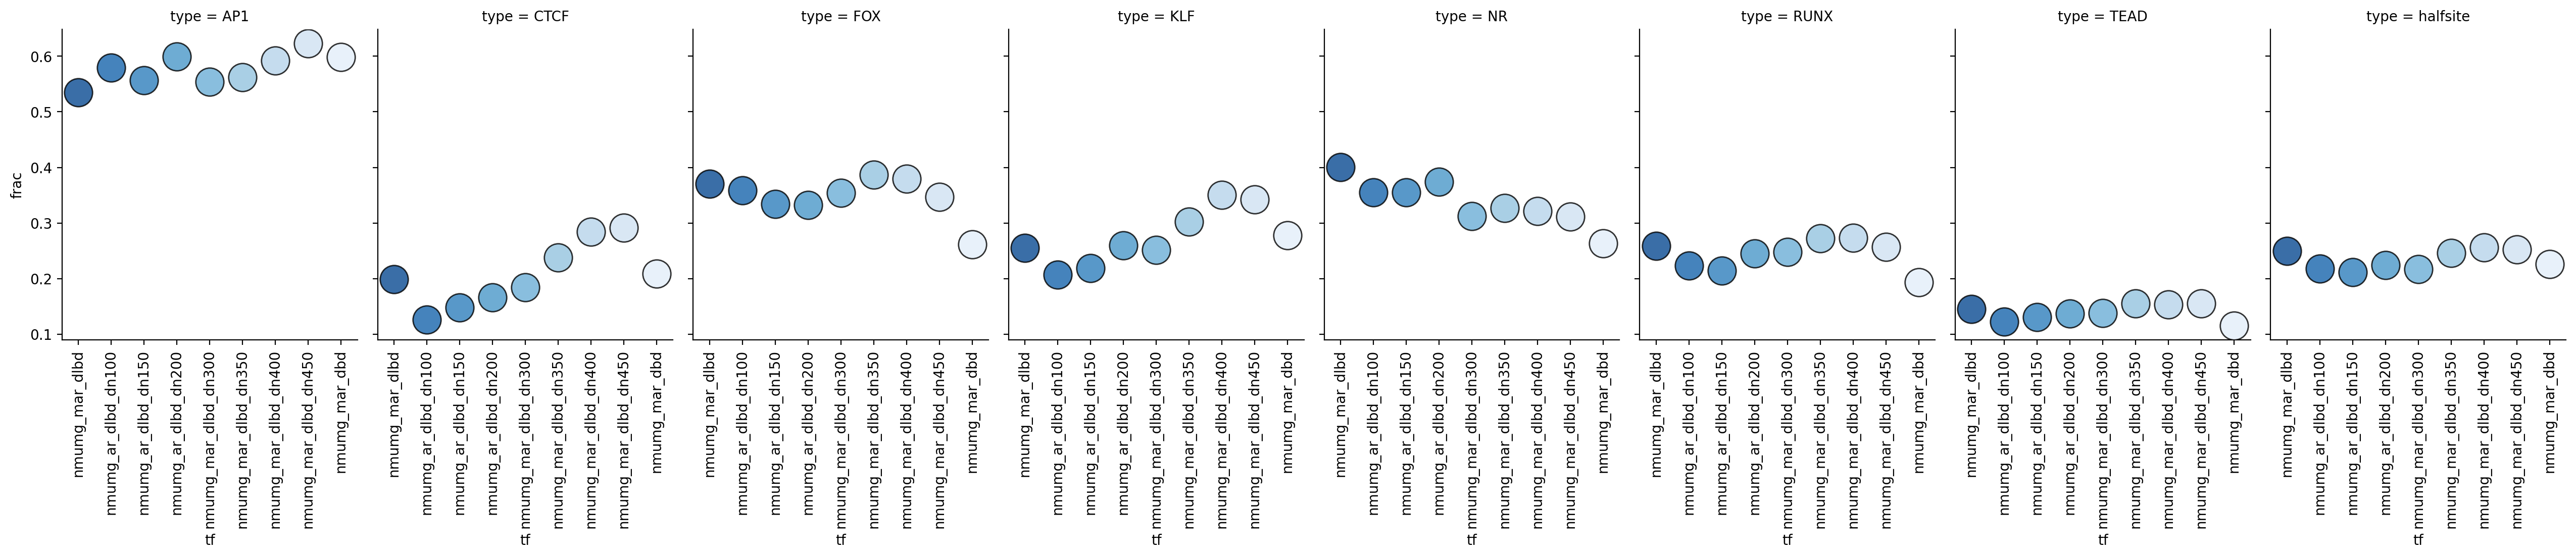

In [9]:
g = sns.catplot(
    nmotsnmumg.filter(regex='ar', axis=0), kind="strip",
    col="type", y='frac', x="tf",
    height=4, aspect=.8, sharey=True,native_scale=True, palette='Blues_r', alpha=.8, size=20, edgecolor='k', linewidth=1
)
norder_ar = ['nmumg_mar_dlbd', 'nmumg_ar_dlbd_dn100', 'nmumg_ar_dlbd_dn150', 'nmumg_ar_dlbd_dn200',
        'nmumg_mar_dlbd_dn300',
       'nmumg_mar_dlbd_dn350', 'nmumg_mar_dlbd_dn400', 'nmumg_mar_dlbd_dn450','nmumg_mar_dbd',]
g.set_xticklabels(norder_ar, rotation=90)
g.fig.savefig('figures/Fig6/6B.pdf')

## S8A

In [10]:
order_pr = ['nmumg_hpr_del_lbd', 'nmumg_hpr_dlbd_dn100',
       'nmumg_hpr_dlbd_dn300', 'nmumg_hpr_dlbd_dn450', 'nmumg_hpr_dbd', ]
order_gr = ['nmumg_hgr_dlbd', 'nmumg_hgr_dlbd_dn50','nmumg_gr_dlbd_dn100', 
       'nmumg_hgr_dlbd_dn150', 'nmumg_hgr_dlbd_dn250', 'nmumg_hgr_dlbd_dn300', 'nmumg_hgr_dbd','nmumg_hgr_dlbd_dn400']

/tmp/ipykernel_2178/4255017732.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


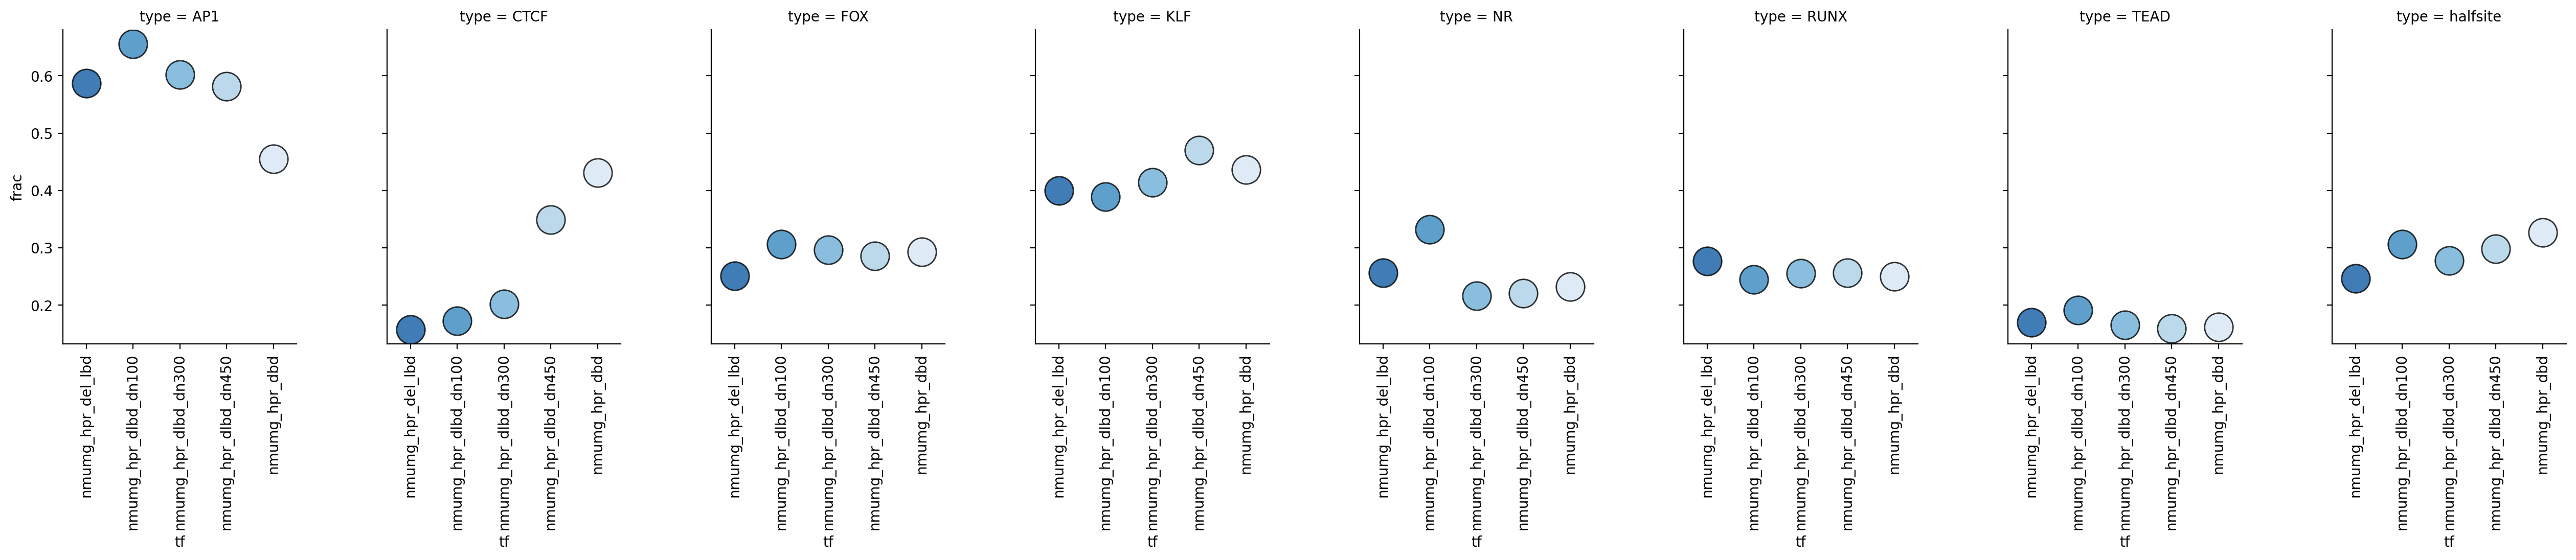

In [11]:
g = sns.catplot(
    nmotsnmumg.filter(regex='pr', axis=0), kind="strip",
    col="type", y='frac', x="tf",
    height=4, aspect=.8, sharey=True,native_scale=True, palette='Blues_r', alpha=.8, size=20, edgecolor='k', linewidth=1
)
g.set_xticklabels(order_pr, rotation=90)
g.fig.savefig('figures/Supp/S8A_1.pdf')

/tmp/ipykernel_2178/2734899927.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


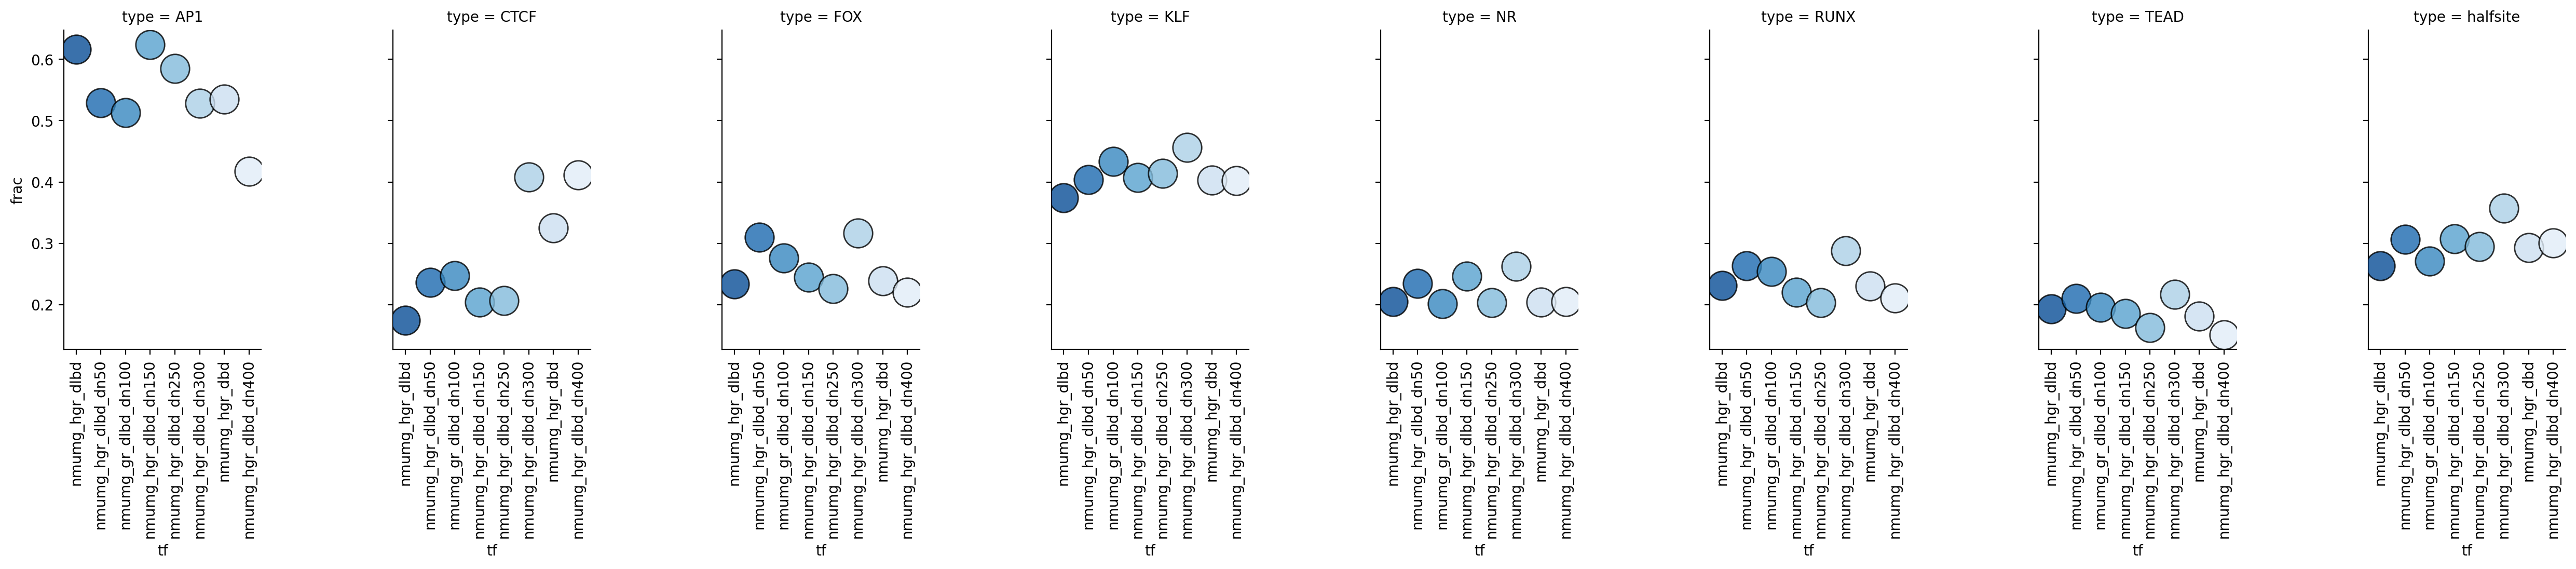

In [12]:
g = sns.catplot(
    nmotsnmumg.filter(regex='gr', axis=0), kind="strip",
    col="type", y='frac', x="tf",
    height=4, aspect=.8, sharey=True,native_scale=True, palette='Blues_r', alpha=.8, size=20, edgecolor='k', linewidth=1
)
g.set_xticklabels(order_gr, rotation=90)
g.fig.savefig('figures/Supp/S8A_2.pdf')

## 6D

In [13]:
data1 = pd.read_parquet('data/cell_peaks_dbddlbdwtlig/nmumg_ar_trunc_clustered_peak_wsignals.parquet')
scols1 = ['nmumg_mar_dlbd','nmumg_ar_dlbd_dn100', 'nmumg_ar_dlbd_dn150', 'nmumg_ar_dlbd_dn200',
        'nmumg_mar_dlbd_dn300',
       'nmumg_mar_dlbd_dn350', 'nmumg_mar_dlbd_dn400', 'nmumg_mar_dlbd_dn450','nmumg_mar_dbd', ]
z = data1.set_index('nindex').loc[:, scols1]
z = (z-z.mean()) / z.std()

mot_folders = ['data/cell_peaks_dbddlbdwtlig/mot_enrich/NR_nmumg_ar_trunc_cluster', 
'data/cell_peaks_dbddlbdwtlig/mot_enrich/NR_hs_nmumg_ar_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/AP1_nmumg_ar_trunc_cluster', 
'data/cell_peaks_dbddlbdwtlig/mot_enrich/FOX_nmumg_ar_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/KLF_nmumg_ar_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/RUNX_nmumg_ar_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/TEAD_nmumg_ar_trunc_cluster',
              'data/cell_peaks_dbddlbdwtlig/mot_enrich/CTCF_nmumg_ar_trunc_cluster']

mots_enrich = pd.concat([load_and_rename_mot(x, x.split('/')[-1]) for x in mot_folders], axis=1)
clustered_w_motifs_ar = pd.concat([data1.set_index('nindex'), mots_enrich.fillna(0)], axis=1).fillna(0)


dl_ind_ar = list(z.query("nmumg_mar_dlbd>3 & nmumg_mar_dbd<2").sort_values(by='nmumg_mar_dlbd', ascending=False).index)
dbd_ind_ar = list(z.query("nmumg_mar_dlbd<2 & nmumg_mar_dbd>=3").sort_values(by='nmumg_mar_dbd', ascending=False).index)


data2 = pd.read_parquet('data/cell_peaks_dbddlbdwtlig/nmumg_pr_trunc_clustered_peak_wsignals.parquet')

z = data2.set_index('nindex').loc[:, order_pr]
z = (z-z.mean()) / z.std()

mot_folders = ['data/cell_peaks_dbddlbdwtlig/mot_enrich/NR_nmumg_pr_trunc_cluster', 
'data/cell_peaks_dbddlbdwtlig/mot_enrich/NR_hs_nmumg_pr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/AP1_nmumg_pr_trunc_cluster', 
'data/cell_peaks_dbddlbdwtlig/mot_enrich/FOX_nmumg_pr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/KLF_nmumg_pr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/RUNX_nmumg_pr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/TEAD_nmumg_pr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/CTCF_nmumg_pr_trunc_cluster' ]

mots_enrich = pd.concat([load_and_rename_mot(x, x.split('/')[-1]) for x in mot_folders], axis=1)
clustered_w_motifs_pr = pd.concat([data2.set_index('nindex'), mots_enrich.fillna(0)], axis=1).fillna(0)


dl_ind_pr = list(z.query("nmumg_hpr_del_lbd>3 & nmumg_hpr_dbd<2").sort_values(by='nmumg_hpr_del_lbd', ascending=False).index)
dbd_ind_pr = list(z.query("nmumg_hpr_del_lbd<2 & nmumg_hpr_dbd>=3").sort_values(by='nmumg_hpr_dbd', ascending=False).index)


data3 = pd.read_parquet('data/cell_peaks_dbddlbdwtlig/nmumg_gr_trunc_clustered_peak_wsignals.parquet')

z = data3.set_index('nindex').loc[:, order_gr]
z = (z-z.mean()) / z.std()

mot_folders = ['data/cell_peaks_dbddlbdwtlig/mot_enrich/NR_nmumg_gr_trunc_cluster', 
'data/cell_peaks_dbddlbdwtlig/mot_enrich/NR_hs_nmumg_gr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/AP1_nmumg_gr_trunc_cluster', 
'data/cell_peaks_dbddlbdwtlig/mot_enrich/FOX_nmumg_gr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/KLF_nmumg_gr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/RUNX_nmumg_gr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/TEAD_nmumg_gr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/CTCF_nmumg_gr_trunc_cluster' ]

mots_enrich = pd.concat([load_and_rename_mot(x, x.split('/')[-1]) for x in mot_folders], axis=1)
clustered_w_motifs_gr = pd.concat([data3.set_index('nindex'), mots_enrich.fillna(0)], axis=1).fillna(0)


dl_ind_gr = list(z.query("nmumg_hgr_dlbd>3 & nmumg_hgr_dlbd_dn400<2").sort_values(by='nmumg_hgr_dlbd', ascending=False).index)
dbd_ind_gr = list(z.query("nmumg_hgr_dlbd<2 & nmumg_hgr_dlbd_dn400>=3").sort_values(by='nmumg_hgr_dlbd_dn400', ascending=False).index)

/tmp/ipykernel_2178/3511191017.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x1.loc[i],y1.loc[i], label=i, c=pal[i], s=30,  zorder=20, marker='p')
/tmp/ipykernel_2178/3511191017.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x2.loc[i],y2.loc[i], label=i, c=pal[i], s=30, zorder=20, marker='s')
/tmp/ipykernel_2178/3511191017.py:28: UserWarning: *c* argument looks like a single numeric RGB or 

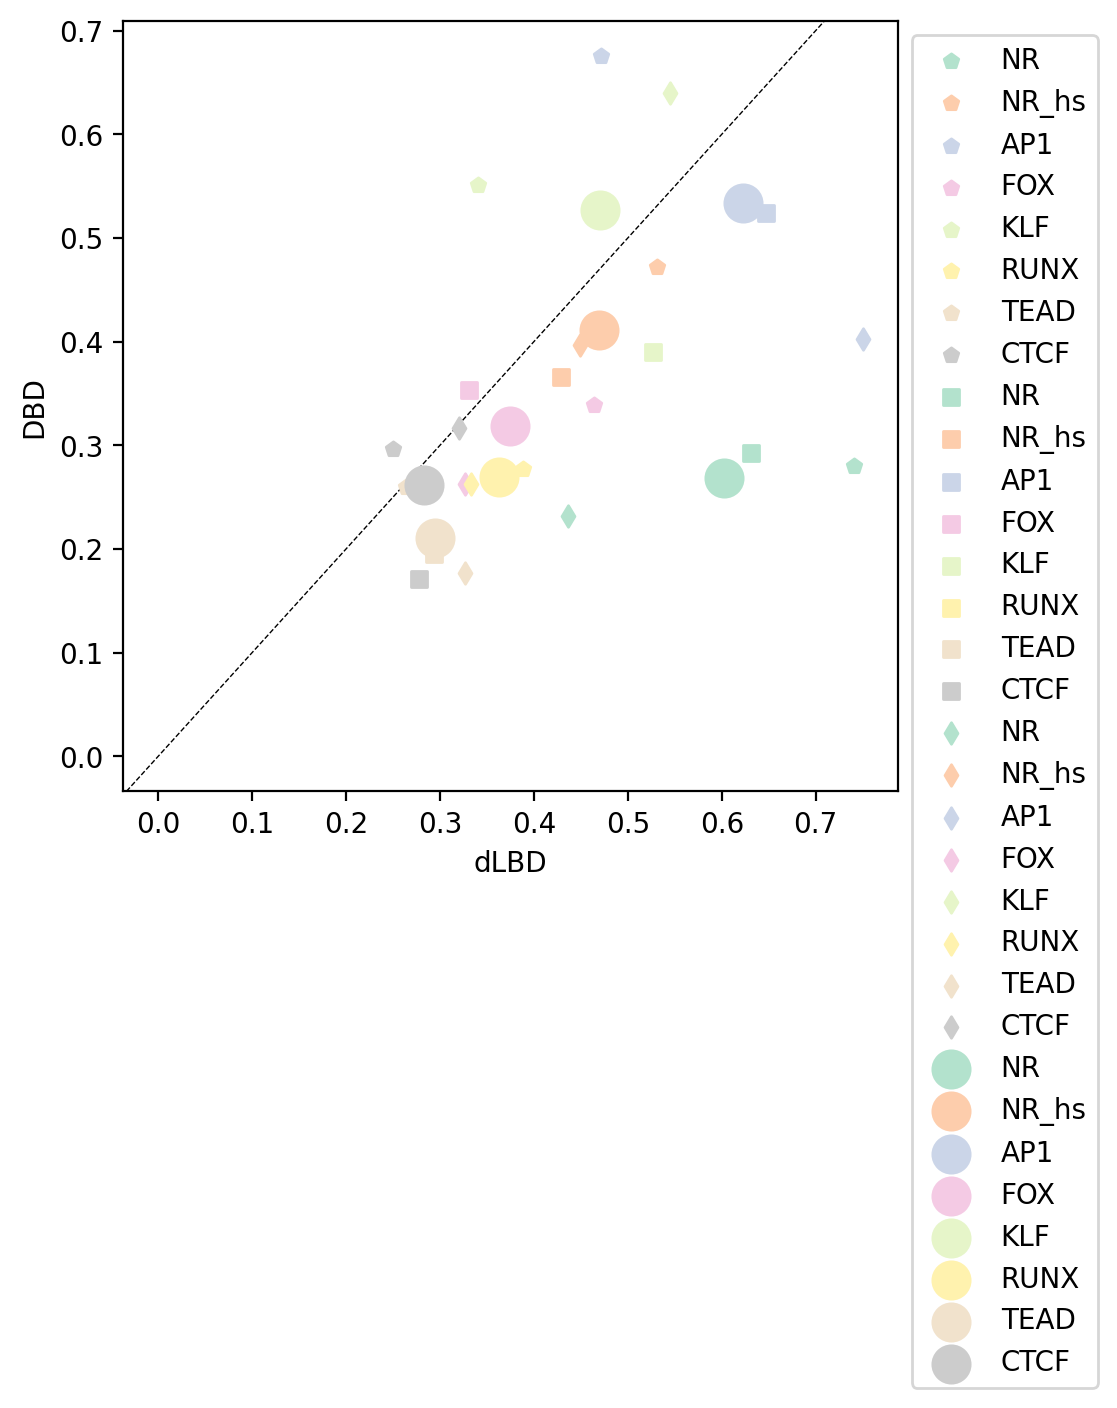

In [14]:
fig, ax = plt.subplots(1, figsize=(5,5))

x1 = pd.DataFrame(((clustered_w_motifs_ar.loc[dl_ind_ar].filter(regex='cluster')>0).sum() / len(dl_ind_ar)))
y1 = pd.DataFrame(((clustered_w_motifs_ar.loc[dbd_ind_ar].filter(regex='cluster')>0).sum() / len(dbd_ind_ar)))
y1.index = [x.split('_nm')[0] for x in y1.index]
x1.index = [x.split('_nm')[0] for x in x1.index]

pal = dict(zip(x1.index, sns.color_palette('Pastel2', n_colors=x1.index.shape[0])))

for i in x1.index:
    ax.scatter(x1.loc[i],y1.loc[i], label=i, c=pal[i], s=30,  zorder=20, marker='p')

    

x2 = pd.DataFrame(((clustered_w_motifs_pr.loc[dl_ind_pr].filter(regex='cluster')>0).sum() / len(dl_ind_pr)))
y2 = pd.DataFrame(((clustered_w_motifs_pr.loc[dbd_ind_pr].filter(regex='cluster')>0).sum() / len(dbd_ind_pr)))
y2.index = [x.split('_nm')[0] for x in y2.index]
x2.index = [x.split('_nm')[0] for x in x2.index]
for i in x1.index:
    ax.scatter(x2.loc[i],y2.loc[i], label=i, c=pal[i], s=30, zorder=20, marker='s')
    

x3 = pd.DataFrame(((clustered_w_motifs_gr.loc[dl_ind_gr].filter(regex='cluster')>0).sum() / len(dl_ind_gr)))
y3 = pd.DataFrame(((clustered_w_motifs_gr.loc[dbd_ind_gr].filter(regex='cluster')>0).sum() / len(dbd_ind_gr)))
y3.index = [x.split('_nm')[0] for x in y3.index]
x3.index = [x.split('_nm')[0] for x in x3.index]
for i in x1.index:
    ax.scatter(x3.loc[i],y3.loc[i], label=i, c=pal[i], s=30, zorder=20, marker='d')
    
    
    
x = pd.DataFrame(pd.concat([x1,x2,x3], axis=1).mean(axis=1))
y = pd.DataFrame(pd.concat([y1,y2,y3], axis=1).mean(axis=1))
y.index = [x.split('_nm')[0] for x in y.index]
x.index = [x.split('_nm')[0] for x in x.index]
for i in x1.index:
    ax.scatter(x.loc[i],y.loc[i], label=i, c=pal[i], s=180, zorder=20)

ax.axline((0,0), slope=1, zorder=1, ls='--', c='k', lw=.5)

ax.legend(bbox_to_anchor=[1,1])
ax.set_xlabel('dLBD')
ax.set_ylabel('DBD')
fig.savefig('figures/Fig6/6D.pdf')

In [15]:
ardbd, arpeak, loaded_fimos_ardbd = prep_peak_fimos('nmumg_mar_dbd', 'AR', metadata)
grdbd, grpeak, loaded_fimos_grdbd = prep_peak_fimos('nmumg_hgr_dlbd_dn400', 'GR', metadata)
prdbd, prpeak, loaded_fimos_prdbd = prep_peak_fimos('nmumg_hpr_dbd', 'PR', metadata)

ardlbd, ardlbdpeak, loaded_fimos_ardlbd = prep_peak_fimos('nmumg_mar_dlbd', 'AR', metadata)
grdlbd, grdlbdpeak, loaded_fimos_grdlbd = prep_peak_fimos('nmumg_hgr_dlbd', 'GR', metadata)
prdlbd, prdlbdpeak, loaded_fimos_prdlbd = prep_peak_fimos('nmumg_hpr_del_lbd', 'PR', metadata)

arlig, arligpeak, loaded_fimos_arlig = prep_peak_fimos('nmumg_mar_wt_lig', 'AR', metadata)
grlig, grligpeak, loaded_fimos_grlig = prep_peak_fimos('nmumg_hgr_wt_lig', 'GR', metadata)
prlig, prligpeak, loaded_fimos_prlig = prep_peak_fimos('nmumg_hpr_wt_lig', 'PR', metadata)

## 6C

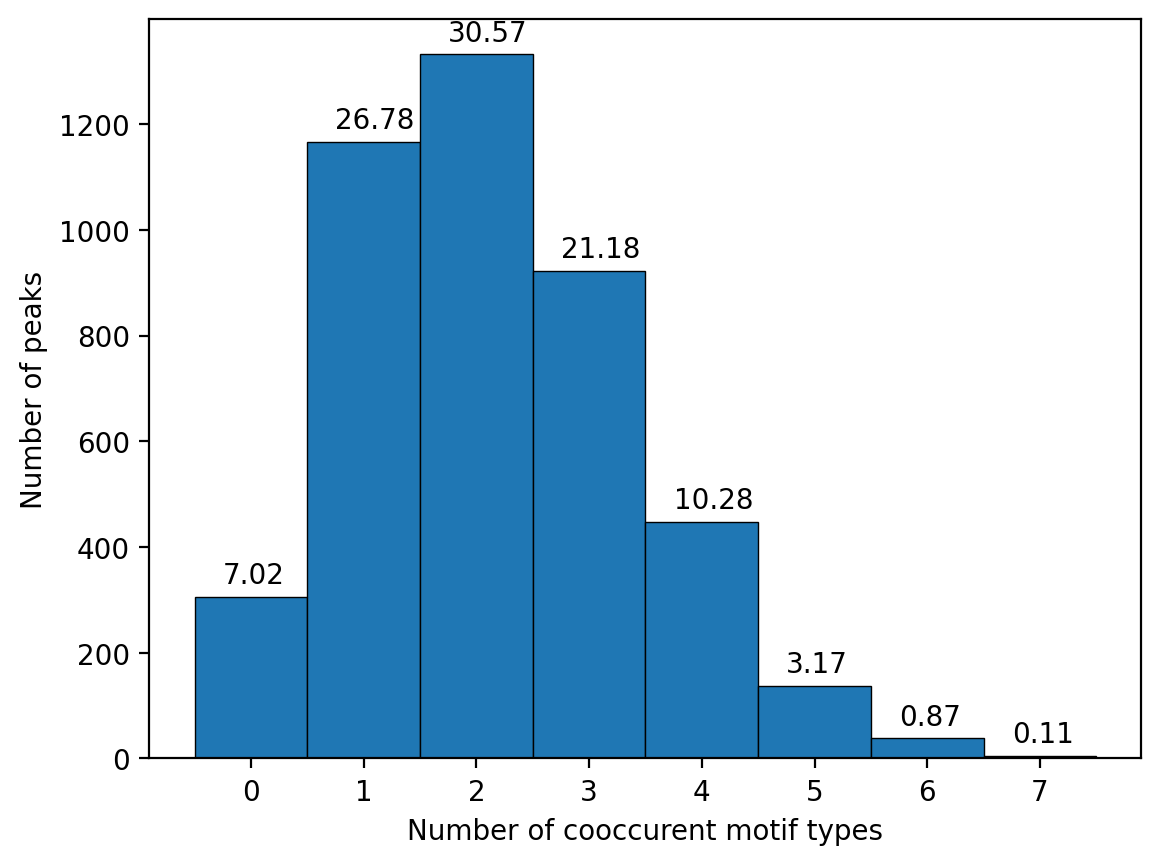

In [17]:
fig = plot_coccurrent_motifs(arpeak, loaded_fimos_ardbd)
plt.show()
fig.savefig('figures/Fig6/6C.pdf')

In [18]:
mid_motifs_ardbd, npeaks_ardbd, pyranges_ardbd = calculate_motif_distances('data/combined_threshed_peaks_wsummits/output_fimo_fasta_nmumg_mar_dbd_fc10_AR_NR_mot/fimo.gff', 'AR_NR_mot', loaded_fimos=loaded_fimos_ardbd, peak= arpeak)
mid_motifs_prdbd, npeaks_prdbd, pyranges_prdbd = calculate_motif_distances('data/combined_threshed_peaks_wsummits/output_fimo_fasta_nmumg_hpr_dbd_fc10_PR_NR_mot/fimo.gff', 'PR_NR_mot', loaded_fimos=loaded_fimos_prdbd, peak= prpeak)
mid_motifs_grdbd, npeaks_grdbd, pyranges_grdbd = calculate_motif_distances('data/combined_threshed_peaks_wsummits/output_fimo_fasta_nmumg_hgr_dlbd_dn400_fc10_GR_NR_mot/fimo.gff', 'GR_NR_mot', loaded_fimos=loaded_fimos_grdbd, peak= grpeak)

mid_motifs_ardlbd, npeaks_ardlbd, pyranges_ardlbd = calculate_motif_distances('data/combined_threshed_peaks_wsummits/output_fimo_fasta_nmumg_mar_dlbd_fc10_AR_NR_mot/fimo.gff', 'AR_NR_mot', loaded_fimos=loaded_fimos_ardlbd, peak=ardlbdpeak )
mid_motifs_prdlbd, npeaks_prdlbd, pyranges_prdlbd = calculate_motif_distances('data/combined_threshed_peaks_wsummits/output_fimo_fasta_nmumg_hpr_del_lbd_fc10_PR_NR_mot/fimo.gff', 'PR_NR_mot', loaded_fimos=loaded_fimos_prdlbd, peak= prdlbdpeak)
mid_motifs_grdlbd, npeaks_grdlbd, pyranges_grdlbd = calculate_motif_distances('data/combined_threshed_peaks_wsummits/output_fimo_fasta_nmumg_hgr_dlbd_fc10_GR_NR_mot/fimo.gff', 'GR_NR_mot', loaded_fimos=loaded_fimos_grdlbd, peak= grdlbdpeak)

mid_motifs_arlig, npeaks_arlig, pyranges_arlig = calculate_motif_distances('data/combined_threshed_peaks_wsummits/output_fimo_fasta_nmumg_mar_wt_lig_fc10_AR_NR_mot/fimo.gff', 'AR_NR_mot', loaded_fimos=loaded_fimos_arlig, peak=arligpeak )
mid_motifs_prlig, npeaks_prlig, pyranges_prlig = calculate_motif_distances('data/combined_threshed_peaks_wsummits/output_fimo_fasta_nmumg_hpr_wt_lig_fc10_PR_NR_mot/fimo.gff', 'PR_NR_mot', loaded_fimos=loaded_fimos_prlig, peak= prligpeak)
mid_motifs_grlig, npeaks_grlig, pyranges_grlig = calculate_motif_distances('data/combined_threshed_peaks_wsummits/output_fimo_fasta_nmumg_hgr_wt_lig_fc10_GR_NR_mot/fimo.gff', 'GR_NR_mot', loaded_fimos=loaded_fimos_grlig, peak= grligpeak)


avebwar = average_bgs(ardbd.NormBG)
avebwpr = average_bgs(prdbd.NormBG)
avebwgr = average_bgs(grdbd.NormBG)

avebwardlbd = average_bgs(ardlbd.NormBG)
avebwprdlbd = average_bgs(prdlbd.NormBG)
avebwgrdlbd = average_bgs(grdlbd.NormBG)

avebwarlig = average_bgs(arlig.NormBG)
avebwprlig = average_bgs(prlig.NormBG)
avebwgrlig = average_bgs(grlig.NormBG)

/tmp/ipykernel_2178/980096563.py:112: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NR' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mid_motifs.loc[cun[cun].index, 'unique'] = col.replace('_Occ', '')
/tmp/ipykernel_2178/980096563.py:112: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NR' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mid_motifs.loc[cun[cun].index, 'unique'] = col.replace('_Occ', '')
/tmp/ipykernel_2178/980096563.py:112: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NR' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mid_motifs.loc[cun[cun].index, 'unique'] = col.replace('_Occ', '')
/tmp/ipykerne

In [19]:
mlist = ['AP1', 'KLF', 'RUNX', 'FOX', 'TEAD', 'halfsite','CTCF']
means_dist_ar, fps_ar = extract_signals_with_dists(mid_motifs_ardbd.filter(regex='Chromosome|NR_'),avebwar, mlist, pyranges_ardbd)
means_dist_pr, fps_pr = extract_signals_with_dists(mid_motifs_prdbd.filter(regex='Chromosome|NR_'),avebwpr, mlist, pyranges_prdbd)
means_dist_gr, fps_gr = extract_signals_with_dists(mid_motifs_grdbd.filter(regex='Chromosome|NR_'),avebwgr, mlist, pyranges_grdbd)

means_dist_ardlbd, fps_ardlbd = extract_signals_with_dists(mid_motifs_ardlbd.filter(regex='Chromosome|NR_'),avebwardlbd, mlist, pyranges_ardlbd)
means_dist_prdlbd, fps_prdlbd = extract_signals_with_dists(mid_motifs_prdlbd.filter(regex='Chromosome|NR_'),avebwprdlbd, mlist, pyranges_prdlbd)
means_dist_grdlbd, fps_grdlbd = extract_signals_with_dists(mid_motifs_grdlbd.filter(regex='Chromosome|NR_'),avebwgrdlbd, mlist, pyranges_grdlbd)

means_dist_arlig, fps_arlig = extract_signals_with_dists(mid_motifs_ardlbd.filter(regex='Chromosome|NR_'),avebwarlig, mlist, pyranges_arlig)
means_dist_prlig, fps_prlig = extract_signals_with_dists(mid_motifs_prdlbd.filter(regex='Chromosome|NR_'),avebwprlig, mlist, pyranges_prlig)
means_dist_grlig, fps_grlig = extract_signals_with_dists(mid_motifs_grdlbd.filter(regex='Chromosome|NR_'),avebwgrlig, mlist, pyranges_grlig)

AP1


join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.


KLF


join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.


RUNX


...

join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.


halfsite


join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.


CTCF


join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.


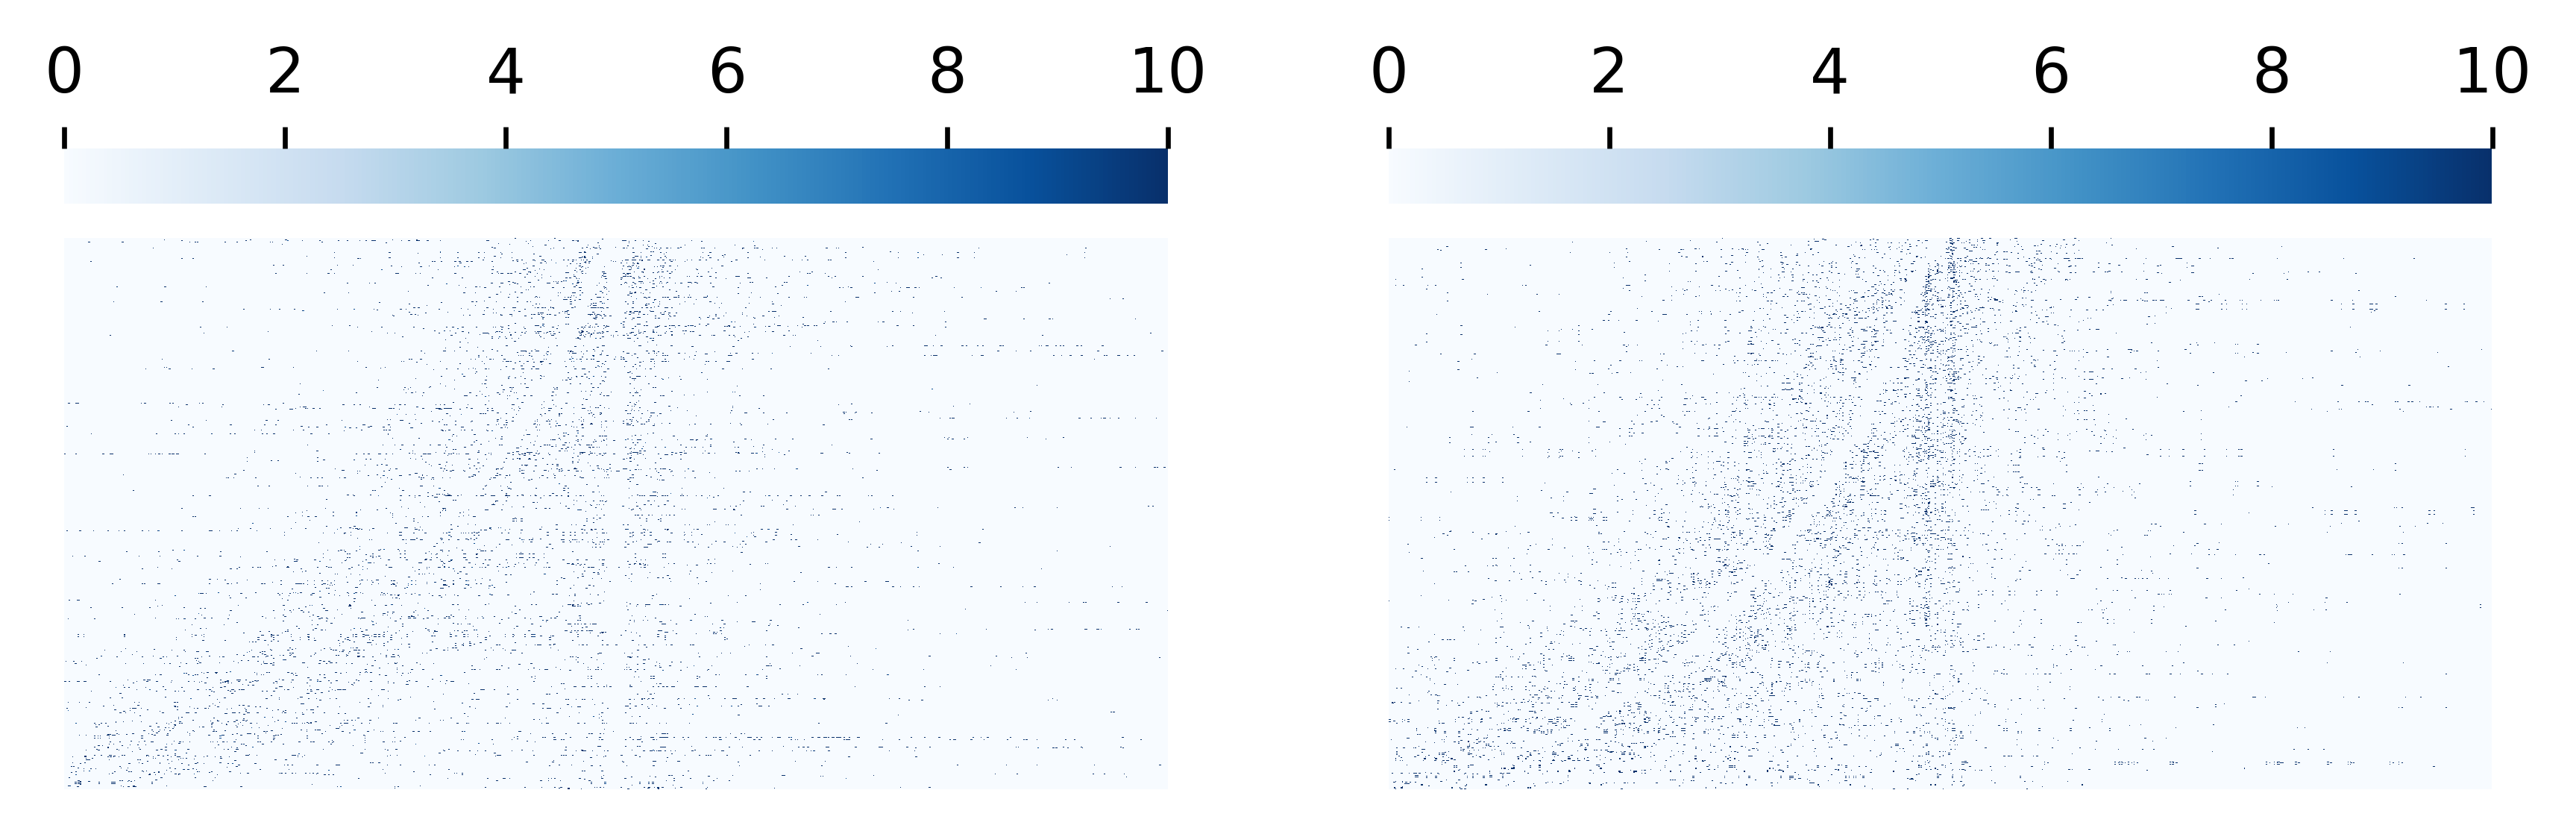

In [20]:
fig, ax = plt.subplots(1,2, dpi=300, figsize=(7,2))

sns.heatmap(fps_ardlbd['AP1'].iloc[:, :-1], cmap='Blues', ax=ax[0], vmax=10,
            xticklabels=False, yticklabels=False, rasterized=True, cbar_kws={'location':'top'})
sns.heatmap(fps_ar['AP1'].iloc[:, :-1], cmap='Blues', ax=ax[1], vmax=10,
            xticklabels=False, yticklabels=False, rasterized=True, cbar_kws={'location':'top'})

fig.savefig('figures/Fig6/6F.png')

/tmp/ipykernel_2178/1687865974.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0–50', '0–50', '0–50', '0–50', '0–50', ..., NaN, NaN, NaN, NaN, NaN]
Length: 2272
Categories (10, object): ['0–50' < '50–100' < '100–150' < '150–200' ... '300–350' < '350–400' < '400–450' < '450–500']' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  ap1_dlbd.loc[:, 'bins'] = binned.values
/tmp/ipykernel_2178/1687865974.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mean = ap1_dlbd.drop('absdist', axis=1).groupby('bins').mean()
/tmp/ipykernel_2178/1687865974.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observ

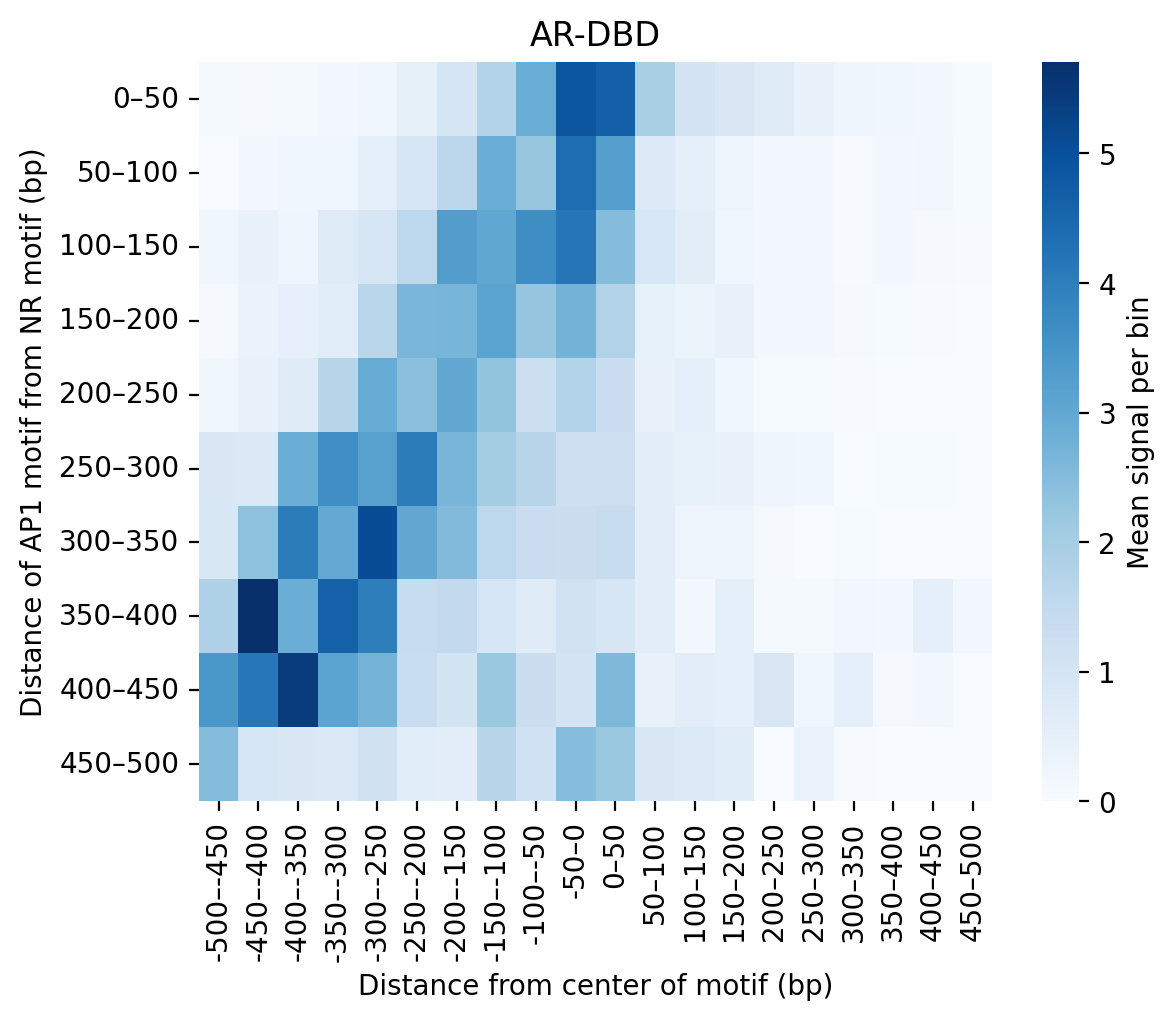

In [28]:
ap1_dlbd = fps_ar['AP1']
bins = np.arange(0,550, 50)   # <100, 100–200, 200–300
labels = [f"{int(left)}–{int(right)}" for left, right in zip(bins[:-1], bins[1:])]

binned = pd.cut(ap1_dlbd.absdist, bins=bins, labels=labels)  # right=True by default: (a, b]
ap1_dlbd.loc[:, 'bins'] = binned.values
bin_mean = ap1_dlbd.drop('absdist', axis=1).groupby('bins').mean()
bin_mean.columns = bin_mean.columns - 500

# bins = [-np.inf, -400, -300, -200,-100, 100, 200, 300, 400, np.inf]
bins = np.arange(-500, 550, 50)
labels = [f"{int(left)}–{int(right)}" for left, right in zip(bins[:-1], bins[1:])]

col_bins = pd.cut(
    bin_mean.columns,
    labels=labels,
    bins=bins,
    right=False   # [0,100), [100,200), ...
)
bin_mean.columns = col_bins

fig, ax = plt.subplots(1)
sns.heatmap(bin_mean.T.reset_index().groupby('index').mean().T,
            cmap='Blues',ax=ax, cbar_kws = {'label':'Mean signal per bin'})
ax.set_xlabel('Distance from center of motif (bp)')
ax.set_ylabel('Distance of AP1 motif from NR motif (bp)')
ax.set_title('AR-DBD')
fig.savefig('figures/newfig_dbd.pdf')

/tmp/ipykernel_2178/2538208390.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mean = ap1_dlbd.drop('absdist', axis=1).groupby('bins').mean()
/tmp/ipykernel_2178/2538208390.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.heatmap(bin_mean.T.reset_index().groupby('index').mean().T,


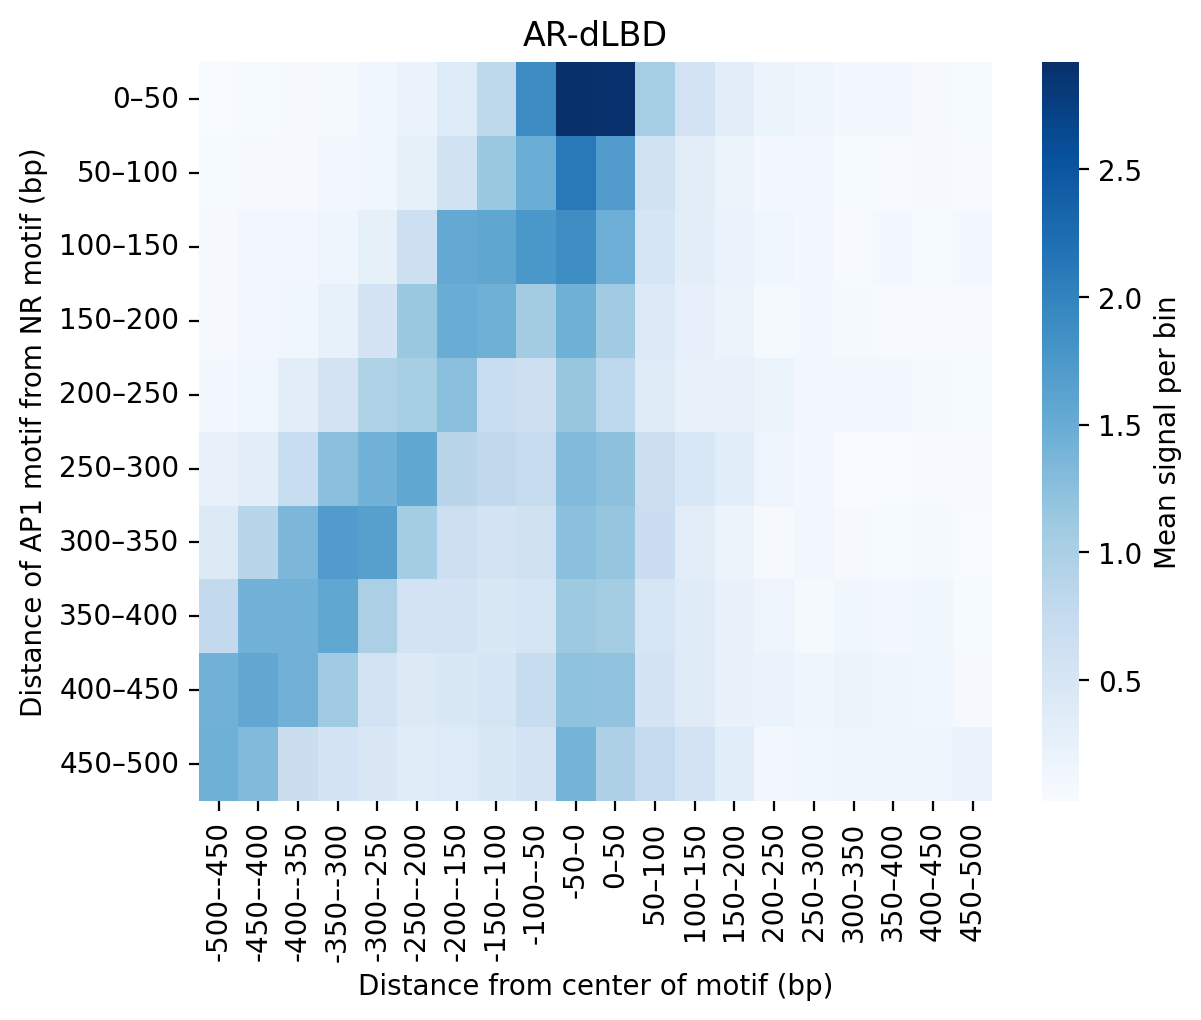

In [22]:
ap1_dlbd = fps_ardlbd['AP1']
bins = np.arange(0,550, 50)   # <100, 100–200, 200–300
labels = [f"{int(left)}–{int(right)}" for left, right in zip(bins[:-1], bins[1:])]

binned = pd.cut(ap1_dlbd.absdist, bins=bins, labels=labels)  # right=True by default: (a, b]
ap1_dlbd.loc[:, 'bins'] = binned.values
bin_mean = ap1_dlbd.drop('absdist', axis=1).groupby('bins').mean()
bin_mean.columns = bin_mean.columns - 500

# bins = [-np.inf, -400, -300, -200,-100, 100, 200, 300, 400, np.inf]
bins = np.arange(-500, 550, 50)
labels = [f"{int(left)}–{int(right)}" for left, right in zip(bins[:-1], bins[1:])]

col_bins = pd.cut(
    bin_mean.columns,
    labels=labels,
    bins=bins,
    right=False   # [0,100), [100,200), ...
)
bin_mean.columns = col_bins
fig, ax = plt.subplots(1)

sns.heatmap(bin_mean.T.reset_index().groupby('index').mean().T,
            cmap='Blues',ax=ax, cbar_kws = {'label':'Mean signal per bin'})
ax.set_xlabel('Distance from center of motif (bp)')
ax.set_ylabel('Distance of AP1 motif from NR motif (bp)')
ax.set_title('AR-dLBD')
fig.savefig('figures/newfig_ardlbd.pdf')

/tmp/ipykernel_2178/2390209131.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0–50', '0–50', '0–50', '0–50', '0–50', ..., NaN, NaN, NaN, NaN, NaN]
Length: 1790
Categories (10, object): ['0–50' < '50–100' < '100–150' < '150–200' ... '300–350' < '350–400' < '400–450' < '450–500']' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  ap1_dlbd.loc[:, 'bins'] = binned.values
/tmp/ipykernel_2178/2390209131.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mean = ap1_dlbd.drop('absdist', axis=1).groupby('bins').mean()
/tmp/ipykernel_2178/2390209131.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observ

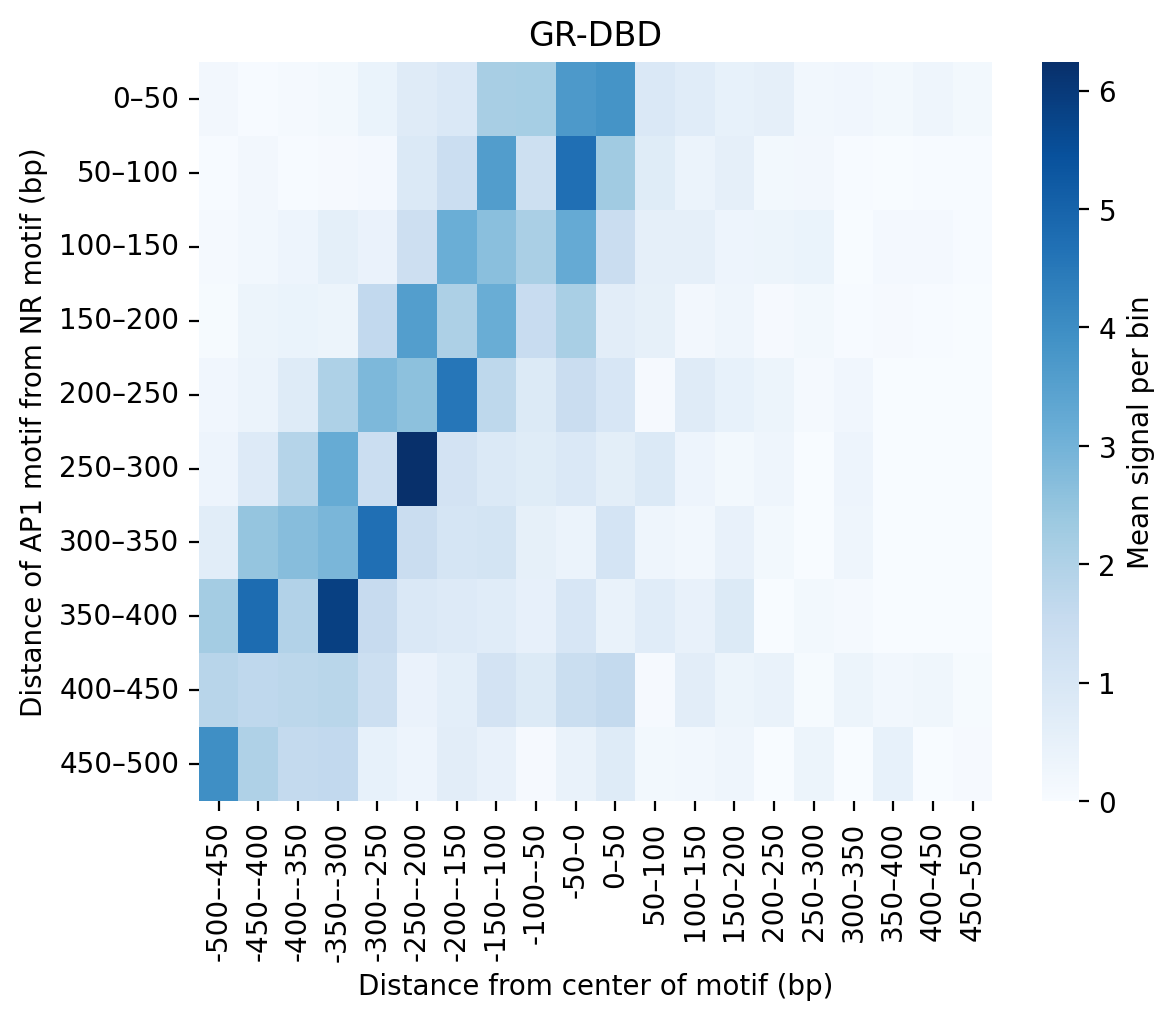

In [29]:
ap1_dlbd = fps_gr['AP1']
bins = np.arange(0,550, 50)   # <100, 100–200, 200–300
labels = [f"{int(left)}–{int(right)}" for left, right in zip(bins[:-1], bins[1:])]

binned = pd.cut(ap1_dlbd.absdist, bins=bins, labels=labels)  # right=True by default: (a, b]
ap1_dlbd.loc[:, 'bins'] = binned.values
bin_mean = ap1_dlbd.drop('absdist', axis=1).groupby('bins').mean()
bin_mean.columns = bin_mean.columns - 500

# bins = [-np.inf, -400, -300, -200,-100, 100, 200, 300, 400, np.inf]
bins = np.arange(-500, 550, 50)
labels = [f"{int(left)}–{int(right)}" for left, right in zip(bins[:-1], bins[1:])]

col_bins = pd.cut(
    bin_mean.columns,
    labels=labels,
    bins=bins,
    right=False   # [0,100), [100,200), ...
)
bin_mean.columns = col_bins

fig, ax = plt.subplots(1)
sns.heatmap(bin_mean.T.reset_index().groupby('index').mean().T,
            cmap='Blues',ax=ax, cbar_kws = {'label':'Mean signal per bin'})
ax.set_xlabel('Distance from center of motif (bp)')
ax.set_ylabel('Distance of AP1 motif from NR motif (bp)')
ax.set_title('GR-DBD')
fig.savefig('figures/newfig_grdbd.pdf')

/tmp/ipykernel_2178/3923634587.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mean = ap1_dlbd.drop('absdist', axis=1).groupby('bins').mean()
/tmp/ipykernel_2178/3923634587.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.heatmap(bin_mean.T.reset_index().groupby('index').mean().T,


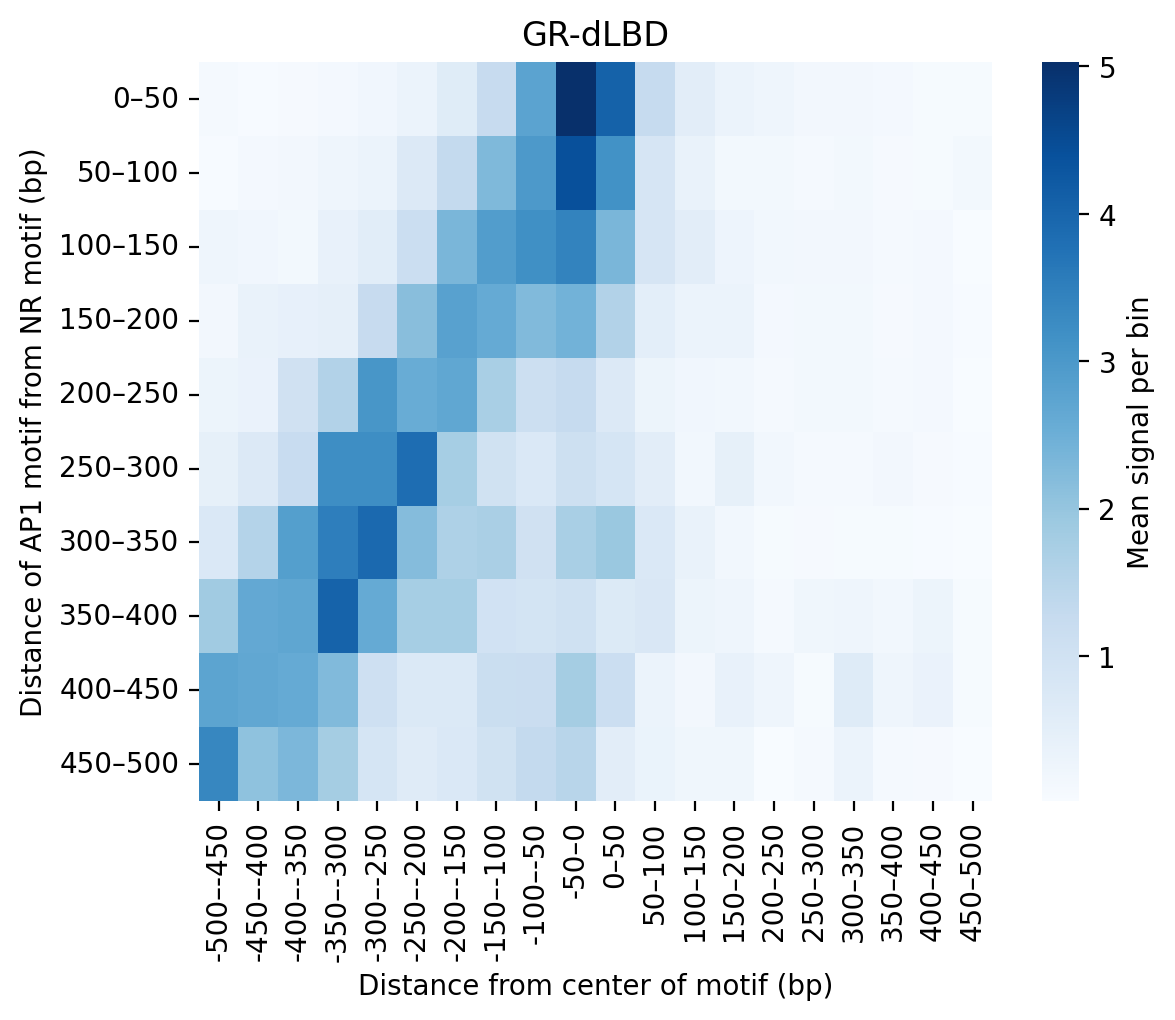

In [24]:
ap1_dlbd = fps_grdlbd['AP1']
bins = np.arange(0,550, 50)   # <100, 100–200, 200–300
labels = [f"{int(left)}–{int(right)}" for left, right in zip(bins[:-1], bins[1:])]

binned = pd.cut(ap1_dlbd.absdist, bins=bins, labels=labels)  # right=True by default: (a, b]
ap1_dlbd.loc[:, 'bins'] = binned.values
bin_mean = ap1_dlbd.drop('absdist', axis=1).groupby('bins').mean()
bin_mean.columns = bin_mean.columns - 500

# bins = [-np.inf, -400, -300, -200,-100, 100, 200, 300, 400, np.inf]
bins = np.arange(-500, 550, 50)
labels = [f"{int(left)}–{int(right)}" for left, right in zip(bins[:-1], bins[1:])]

col_bins = pd.cut(
    bin_mean.columns,
    labels=labels,
    bins=bins,
    right=False   # [0,100), [100,200), ...
)
bin_mean.columns = col_bins
fig, ax = plt.subplots(1)

sns.heatmap(bin_mean.T.reset_index().groupby('index').mean().T,
            cmap='Blues',ax=ax, cbar_kws = {'label':'Mean signal per bin'})
ax.set_xlabel('Distance from center of motif (bp)')
ax.set_ylabel('Distance of AP1 motif from NR motif (bp)')
ax.set_title('GR-dLBD')
fig.savefig('figures/newfig_grdlbd.pdf')

/tmp/ipykernel_2178/1605350723.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0–50', '0–50', '0–50', '0–50', '0–50', ..., NaN, NaN, NaN, NaN, NaN]
Length: 2297
Categories (10, object): ['0–50' < '50–100' < '100–150' < '150–200' ... '300–350' < '350–400' < '400–450' < '450–500']' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  ap1_dlbd.loc[:, 'bins'] = binned.values
/tmp/ipykernel_2178/1605350723.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mean = ap1_dlbd.drop('absdist', axis=1).groupby('bins').mean()
/tmp/ipykernel_2178/1605350723.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observ

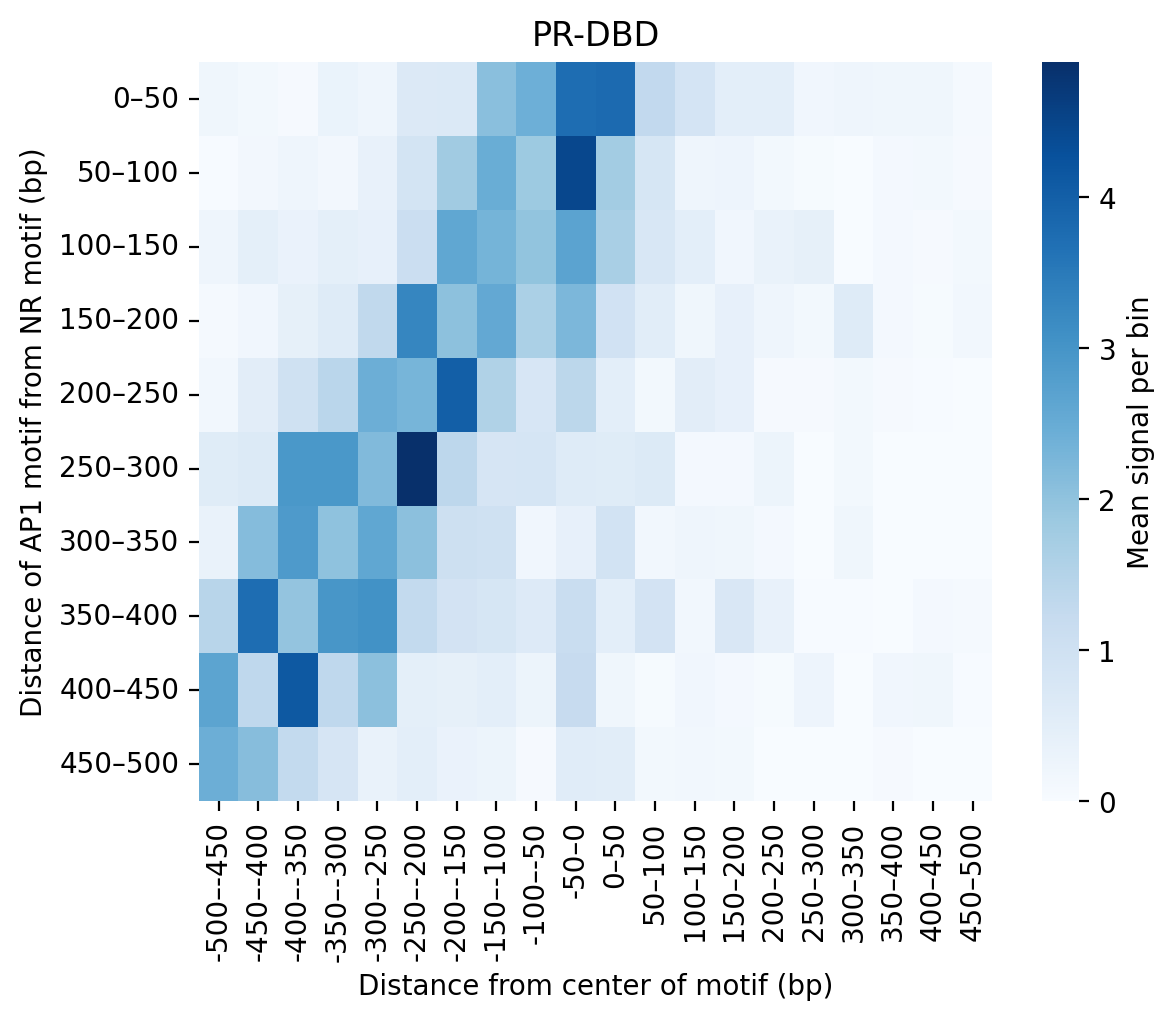

In [30]:
ap1_dlbd = fps_pr['AP1']
bins = np.arange(0,550, 50)   # <100, 100–200, 200–300
labels = [f"{int(left)}–{int(right)}" for left, right in zip(bins[:-1], bins[1:])]

binned = pd.cut(ap1_dlbd.absdist, bins=bins, labels=labels)  # right=True by default: (a, b]
ap1_dlbd.loc[:, 'bins'] = binned.values
bin_mean = ap1_dlbd.drop('absdist', axis=1).groupby('bins').mean()
bin_mean.columns = bin_mean.columns - 500

# bins = [-np.inf, -400, -300, -200,-100, 100, 200, 300, 400, np.inf]
bins = np.arange(-500, 550, 50)
labels = [f"{int(left)}–{int(right)}" for left, right in zip(bins[:-1], bins[1:])]

col_bins = pd.cut(
    bin_mean.columns,
    labels=labels,
    bins=bins,
    right=False   # [0,100), [100,200), ...
)
bin_mean.columns = col_bins

fig, ax = plt.subplots(1)
sns.heatmap(bin_mean.T.reset_index().groupby('index').mean().T,
            cmap='Blues',ax=ax, cbar_kws = {'label':'Mean signal per bin'})
ax.set_xlabel('Distance from center of motif (bp)')
ax.set_ylabel('Distance of AP1 motif from NR motif (bp)')
ax.set_title('PR-DBD')
fig.savefig('figures/newfig_prdbd.pdf')

/tmp/ipykernel_2178/1419042715.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mean = ap1_dlbd.drop('absdist', axis=1).groupby('bins').mean()
/tmp/ipykernel_2178/1419042715.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.heatmap(bin_mean.T.reset_index().groupby('index').mean().T,


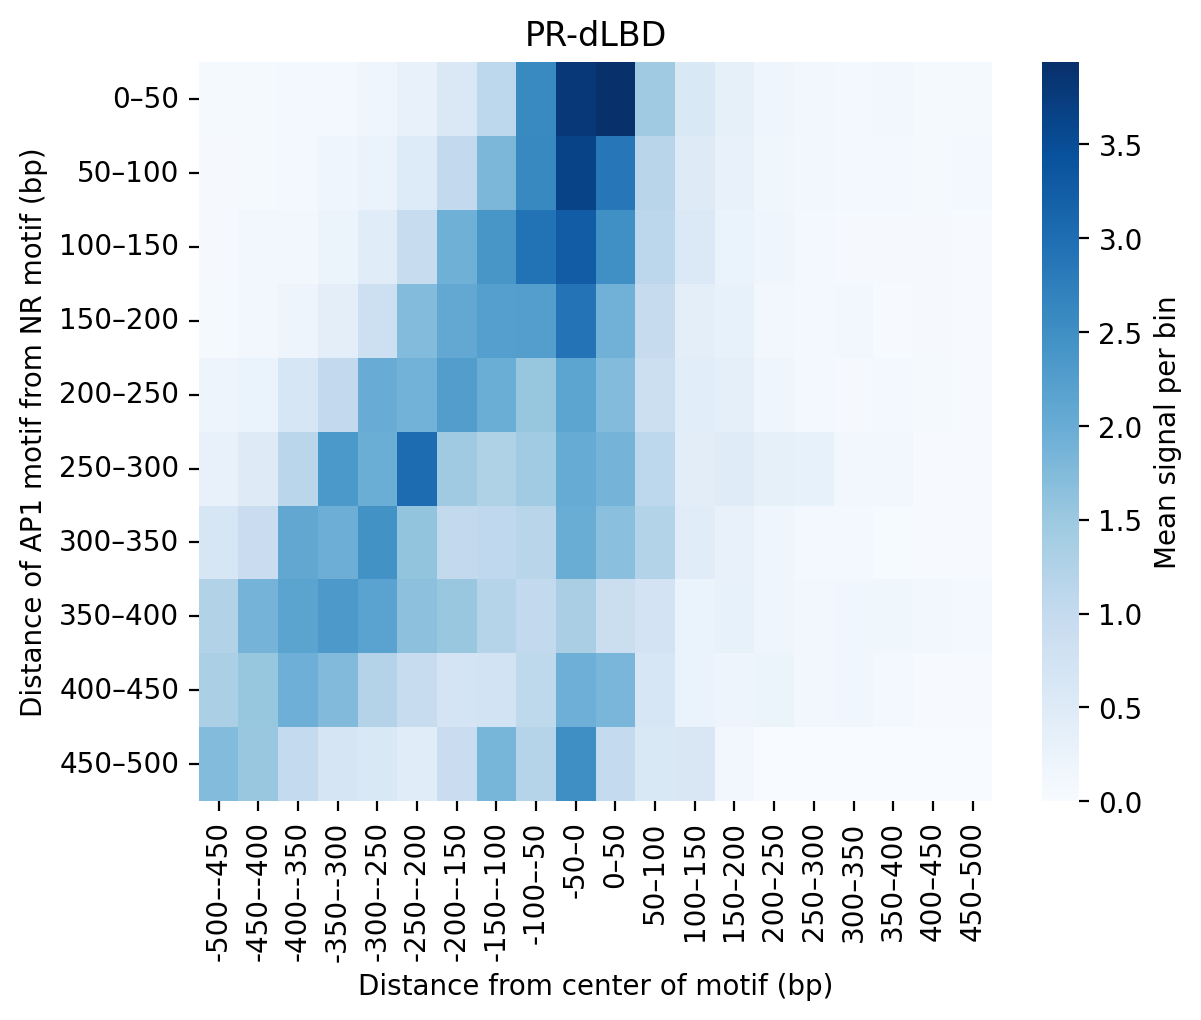

In [26]:
ap1_dlbd = fps_prdlbd['AP1']
bins = np.arange(0,550, 50)   # <100, 100–200, 200–300
labels = [f"{int(left)}–{int(right)}" for left, right in zip(bins[:-1], bins[1:])]

binned = pd.cut(ap1_dlbd.absdist, bins=bins, labels=labels)  # right=True by default: (a, b]
ap1_dlbd.loc[:, 'bins'] = binned.values
bin_mean = ap1_dlbd.drop('absdist', axis=1).groupby('bins').mean()
bin_mean.columns = bin_mean.columns - 500

# bins = [-np.inf, -400, -300, -200,-100, 100, 200, 300, 400, np.inf]
bins = np.arange(-500, 550, 50)
labels = [f"{int(left)}–{int(right)}" for left, right in zip(bins[:-1], bins[1:])]

col_bins = pd.cut(
    bin_mean.columns,
    labels=labels,
    bins=bins,
    right=False   # [0,100), [100,200), ...
)
bin_mean.columns = col_bins
fig, ax = plt.subplots(1)

sns.heatmap(bin_mean.T.reset_index().groupby('index').mean().T,
            cmap='Blues',ax=ax, cbar_kws = {'label':'Mean signal per bin'})
ax.set_xlabel('Distance from center of motif (bp)')
ax.set_ylabel('Distance of AP1 motif from NR motif (bp)')
ax.set_title('PR-dLBD')
fig.savefig('figures/newfig_prdlbd.pdf')

## 6G

In [25]:
# mlist = ['AP1', 'KLF', 'RUNX', 'FOX', 'TEAD', 'halfsite','CTCF']

# rmsear, fig, _ = plot_profiles(means_dist_ar, fps_ar, mlist)

# fig.savefig('figures/Fig6/6G.pdf')


## S9A

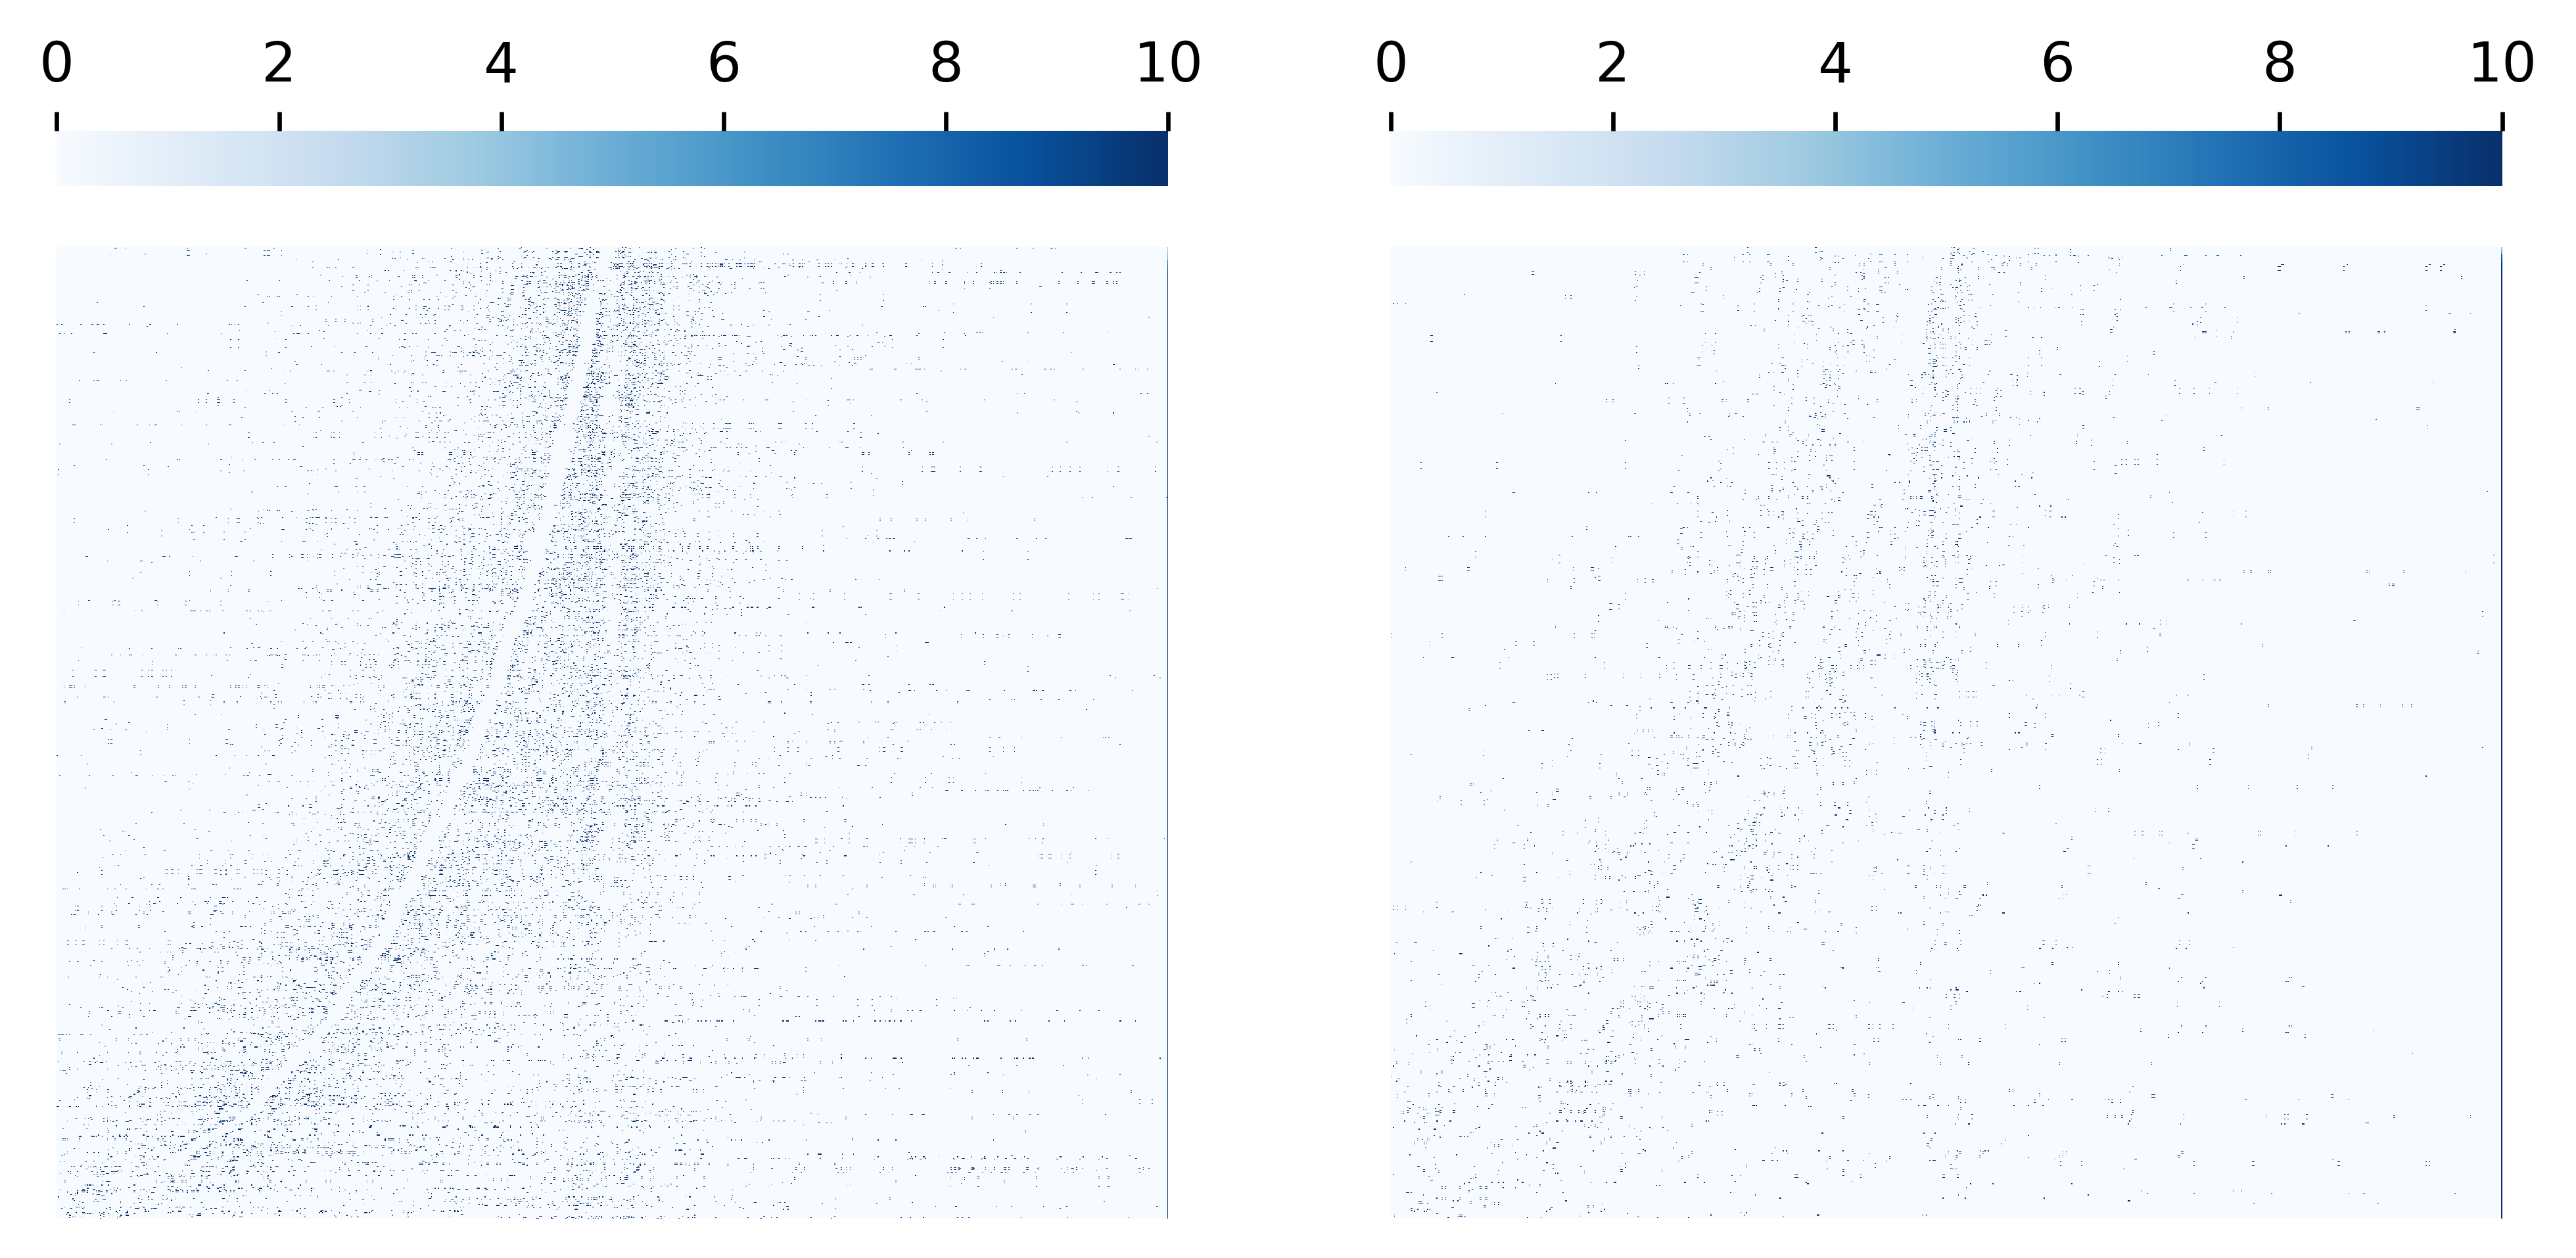

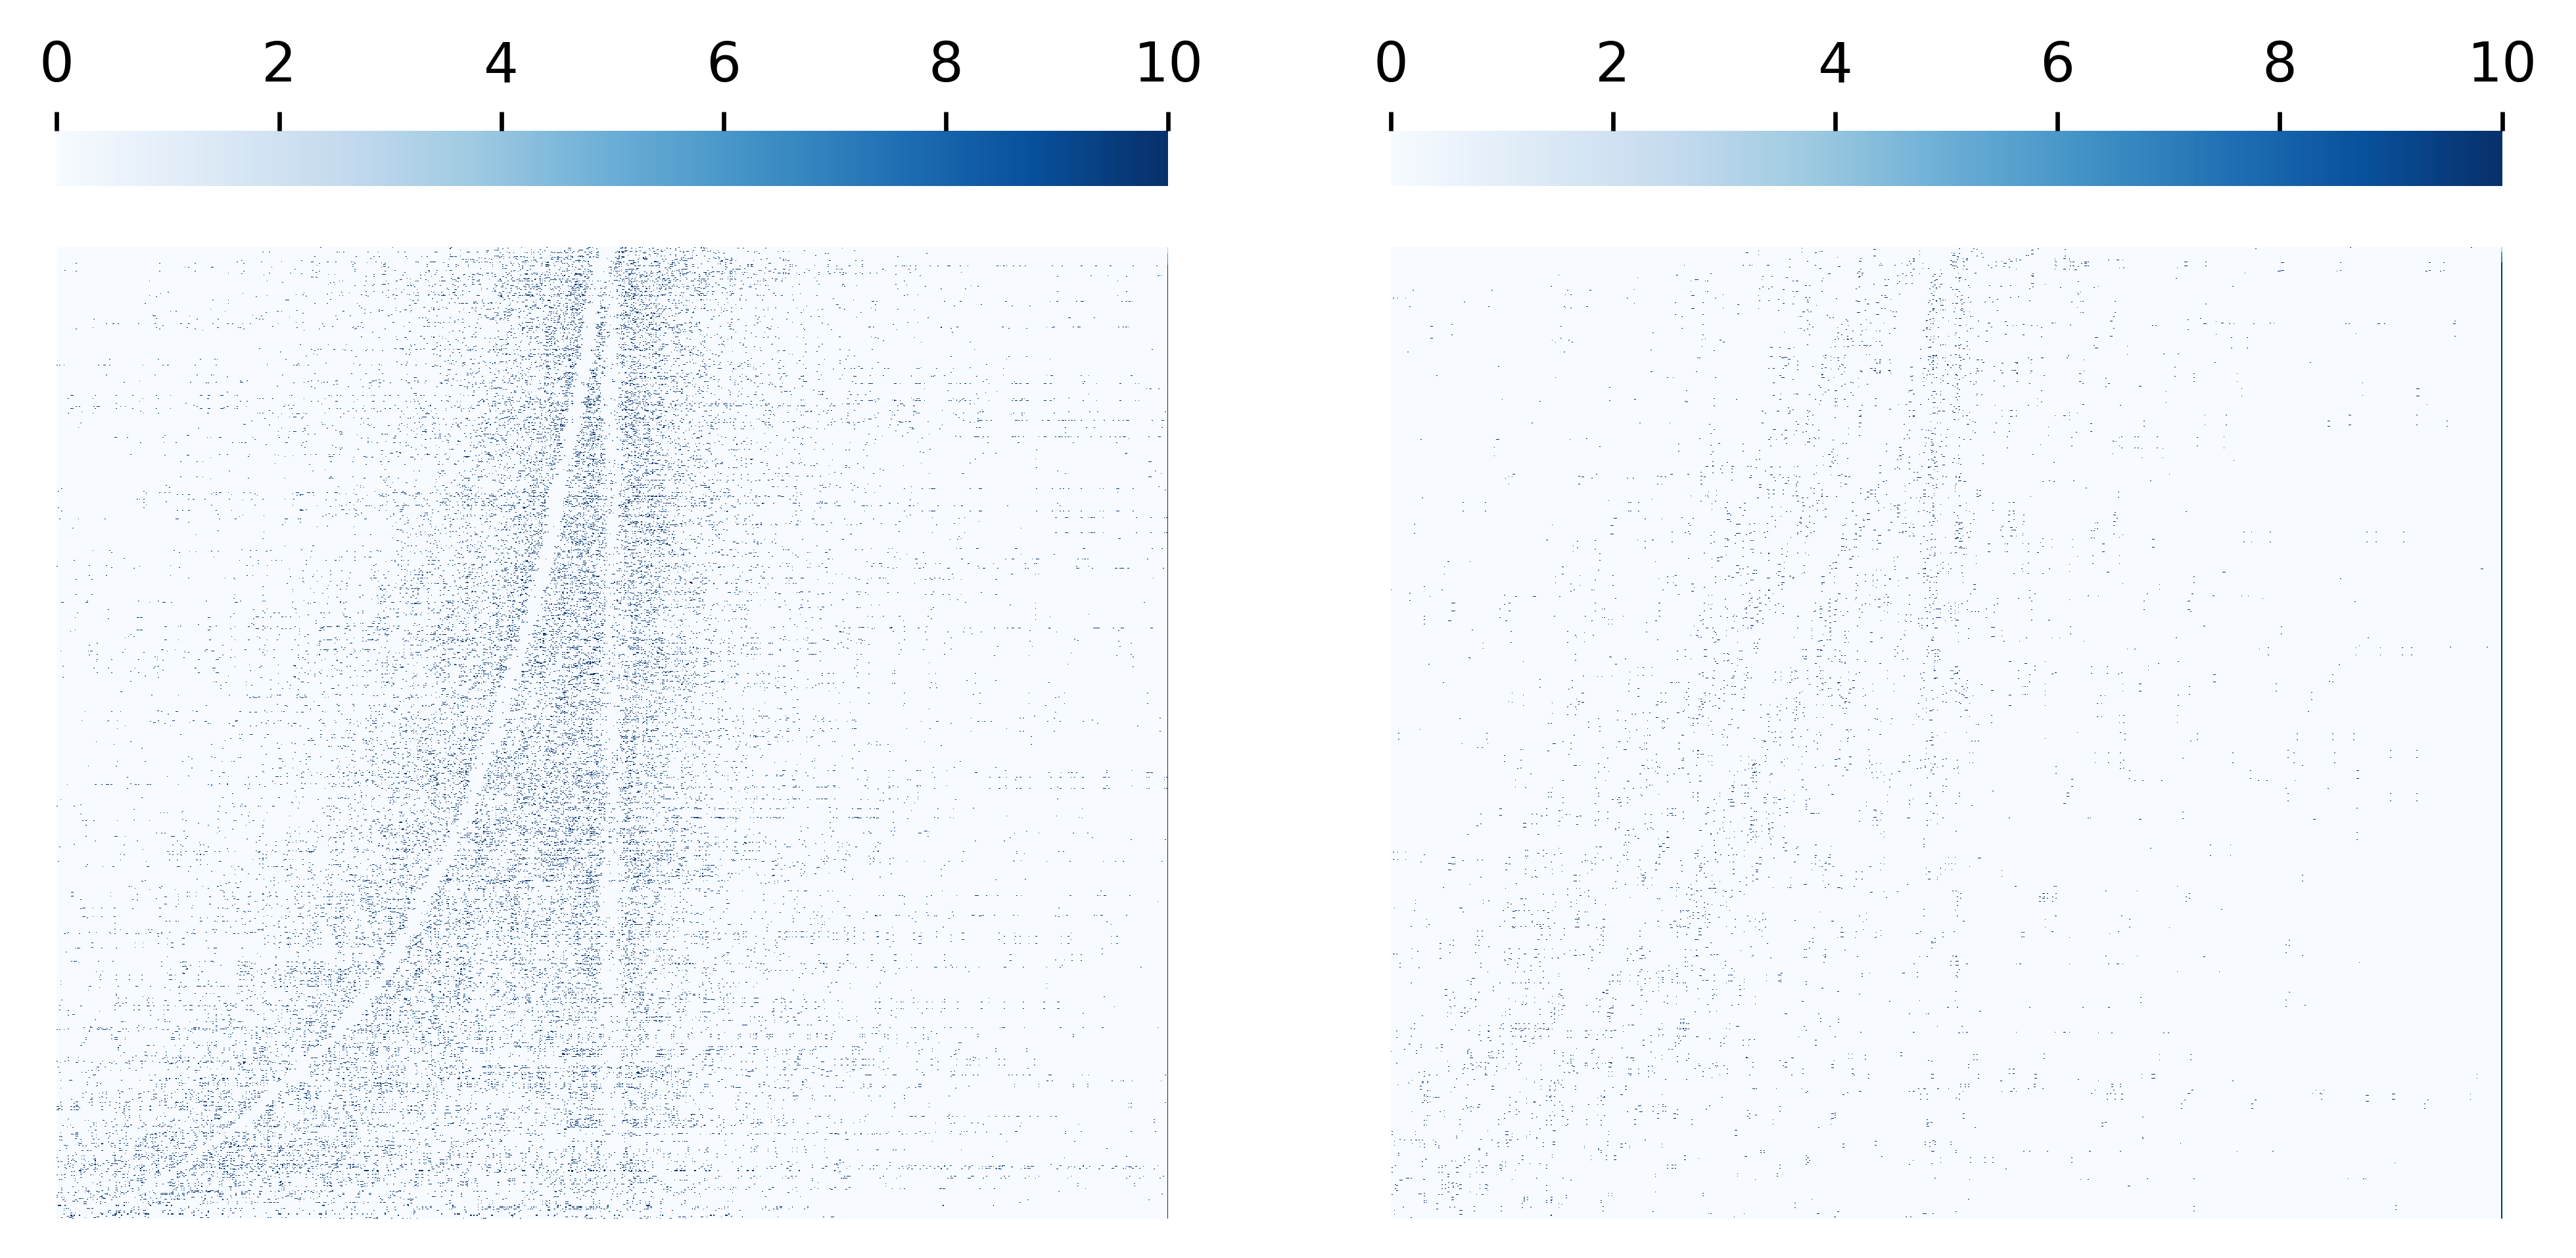

In [26]:
fig, ax = plt.subplots(1,2, dpi=300, figsize=(8,4))


sns.heatmap(fps_grdlbd['AP1'].iloc[:, :-1], cmap='Blues', ax=ax[0], vmax=10,
            xticklabels=False, yticklabels=False, rasterized=True, cbar_kws={'location':'top'})


sns.heatmap(fps_gr['AP1'].iloc[:, :-1], cmap='Blues', ax=ax[1], vmax=10,
            xticklabels=False, yticklabels=False, rasterized=True, cbar_kws={'location':'top'})

fig.savefig('figures/Supp/S9A_1.png')


fig, ax = plt.subplots(1,2, dpi=300, figsize=(8,4))


sns.heatmap(fps_prdlbd['AP1'].iloc[:, :-1], cmap='Blues', ax=ax[0], vmax=10,
            xticklabels=False, yticklabels=False, rasterized=True, cbar_kws={'location':'top'})


sns.heatmap(fps_pr['AP1'].iloc[:, :-1], cmap='Blues', ax=ax[1], vmax=10,
            xticklabels=False, yticklabels=False, rasterized=True, cbar_kws={'location':'top'})

fig.savefig('figures/Supp/S9A_2.png')


## S9B

In [27]:
# mlist = ['AP1', 'KLF', 'RUNX', 'FOX', 'TEAD', 'halfsite','CTCF']

# rmsear, fig, f2 = plot_profiles(means_dist_pr, fps_pr, mlist)

# fig.savefig('figures/Supp/S9B_1.pdf')
# plt.close(f2)

In [28]:
# mlist = ['AP1', 'KLF', 'RUNX', 'FOX', 'TEAD', 'halfsite','CTCF']

# rmsear, fig, f2 = plot_profiles(means_dist_gr, fps_gr, mlist)

# fig.savefig('figures/Supp/S9B_2.pdf')
# plt.close(f2)

## 6H

In [34]:
def plot_the_line(sample, ax, color, motif, label, smooth=100):
    sum_mid = sample[motif].iloc[:, 450:550].mean(axis=1)
    t = pd.concat([sum_mid, sample[motif].loc[:, 'absdist'], sample[motif].query("absdist<450").apply(lambda x: x[450-x['absdist']:550-x['absdist']].mean(), axis=1)], axis=1).dropna()
    t = t.groupby('absdist').mean().reset_index().rolling(window=smooth, center=False).apply(lambda x: stats.trim_mean(x, 0.05)) 
    ax.plot(t.iloc[:,0], t.iloc[:, 2]/t.iloc[:, 1], label=label, color=color)

def process_hepg2(tf, keys, palette, ax, motif='AP1'):
    mlist = [motif]

    # fig, ax = plt.subplots(1)
    sig_dict = dict()
    for i in keys:
        params, cpeak, lf = prep_peak_fimos(i, tf, metadata)
        mid_m, npeaks, cpyranges = calculate_motif_distances(f'data/combined_threshed_peaks_wsummits/output_fimo_fasta_{i}_fc10_PR_NR_mot/fimo.gff', f'{tf}_NR_mot', loaded_fimos=lf, peak= cpeak)
        cavbw = average_bgs(params.NormBG)

        cmd, cfps = extract_signals_with_dists(mid_m.filter(regex='Chromosome|NR_'),cavbw, mlist, cpyranges)
        sig_dict[i] = cfps

    for (key, value), color in zip(sig_dict.items(), palette):
        sum_mid = value[motif].iloc[:, 450:550].mean(axis=1)
        t = pd.concat([sum_mid, value[motif].iloc[:, -1], value[motif].query("absdist<450").apply(lambda x: x[450-x['absdist']:550-x['absdist']].mean(), axis=1)], axis=1).dropna()
        smoothed = t.groupby('absdist').mean().reset_index().rolling(window=100, center=False).apply(lambda x: stats.trim_mean(x, 0.1)).dropna()

        ax.plot(smoothed.absdist, smoothed.iloc[:, 2]/smoothed.iloc[:, 1], label=key, c=color)
    ax.legend(bbox_to_anchor=[1,-1])
    return sig_dict

In [30]:
color_dict = {
    'PR':{'dLBD':'#586B4A', 'DBD':'#CFDEB6'},
    'AR':{'dLBD':'#4A586B', 'DBD':'#B6CFDE'},
    'GR':{'dLBD':'#6B4A58', 'DBD':'#DEB6CF'}
}

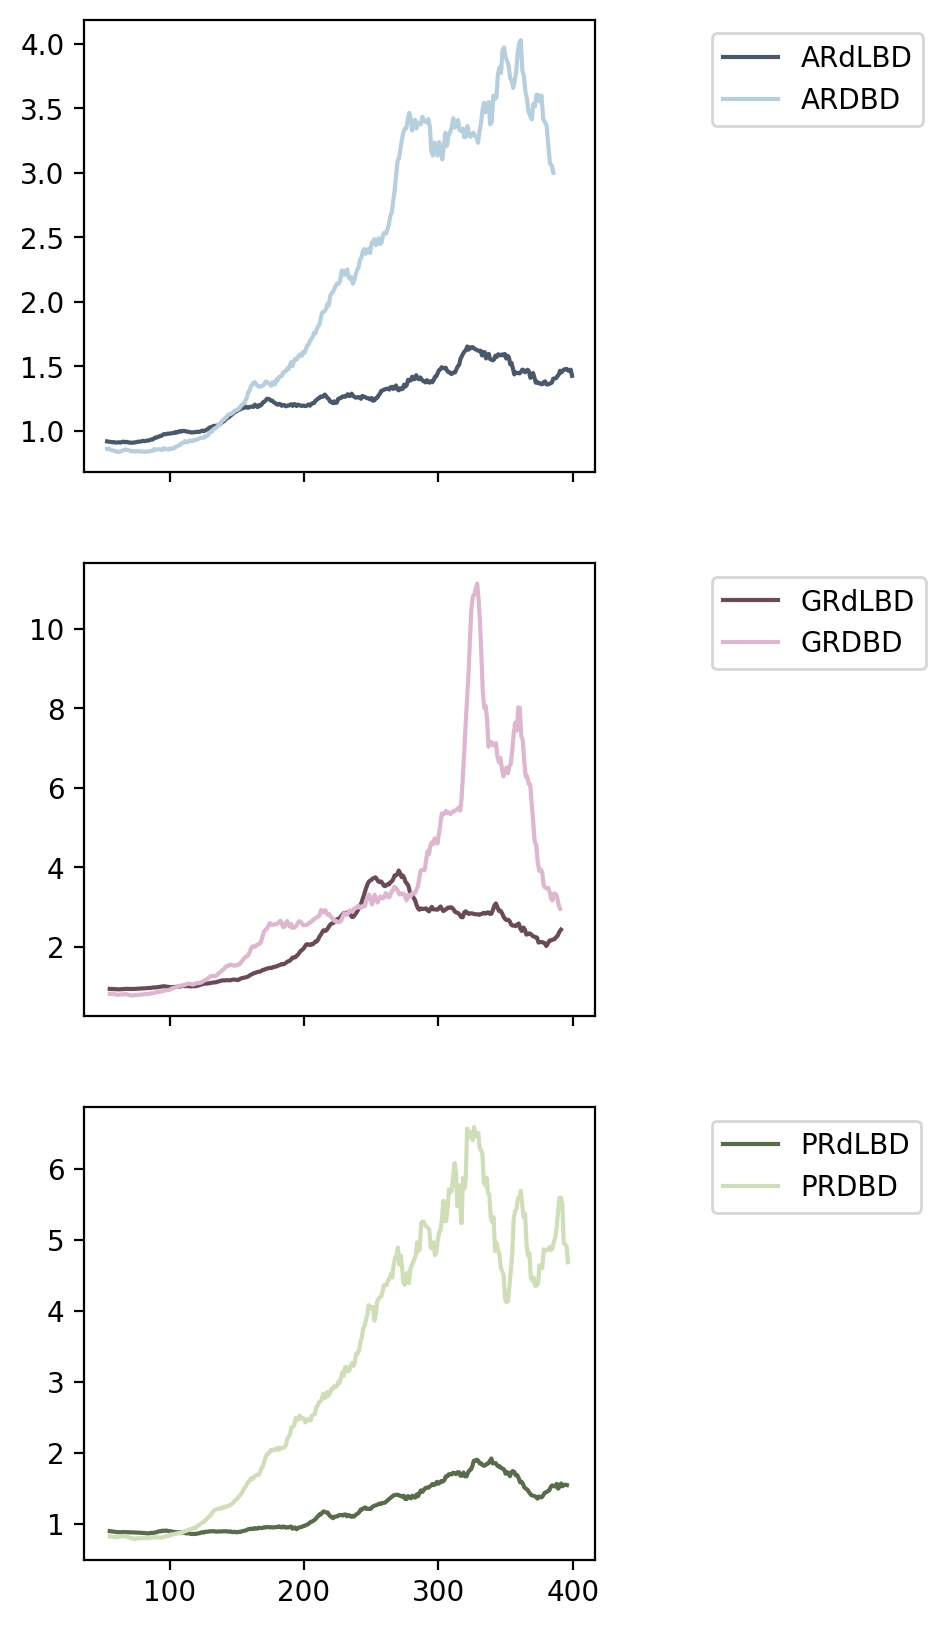

In [32]:
motif = 'AP1'
fig, axes = plt.subplots(3,1, sharex=True, figsize=(3.3,10))

ax=axes[0]
plot_the_line(sample=fps_ardlbd, ax=ax, color=color_dict['AR']['dLBD'], motif = motif, label='ARdLBD')
plot_the_line(sample=fps_ar, ax=ax, color=color_dict['AR']['DBD'], motif = motif, label='ARDBD')
ax.legend(bbox_to_anchor=[1.2,1])

ax=axes[1]
plot_the_line(sample=fps_grdlbd, ax=ax, color=color_dict['GR']['dLBD'], motif = motif, label='GRdLBD')
plot_the_line(sample=fps_gr, ax=ax, color=color_dict['GR']['DBD'], motif = motif, label='GRDBD')
ax.legend(bbox_to_anchor=[1.2,1])

ax = axes[2]
plot_the_line(sample=fps_prdlbd, ax=ax, color=color_dict['PR']['dLBD'], motif = motif, label='PRdLBD')
plot_the_line(sample=fps_pr, ax=ax, color=color_dict['PR']['DBD'], motif = motif, label='PRDBD')
ax.legend(bbox_to_anchor=[1.2,1])
fig.savefig('figures/interactions_nmumg.pdf')


/tmp/ipykernel_2061515/980096563.py:112: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NR' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mid_motifs.loc[cun[cun].index, 'unique'] = col.replace('_Occ', '')


AP1


join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.
/tmp/ipykernel_2061515/980096563.py:112: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NR' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mid_motifs.loc[cun[cun].index, 'unique'] = col.replace('_Occ', '')


AP1


join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.
/tmp/ipykernel_2061515/980096563.py:112: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NR' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mid_motifs.loc[cun[cun].index, 'unique'] = col.replace('_Occ', '')


...

AP1


/tmp/ipykernel_2061515/980096563.py:112: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NR' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mid_motifs.loc[cun[cun].index, 'unique'] = col.replace('_Occ', '')


AP1


join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.
/tmp/ipykernel_2061515/980096563.py:112: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NR' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mid_motifs.loc[cun[cun].index, 'unique'] = col.replace('_Occ', '')
join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.


AP1


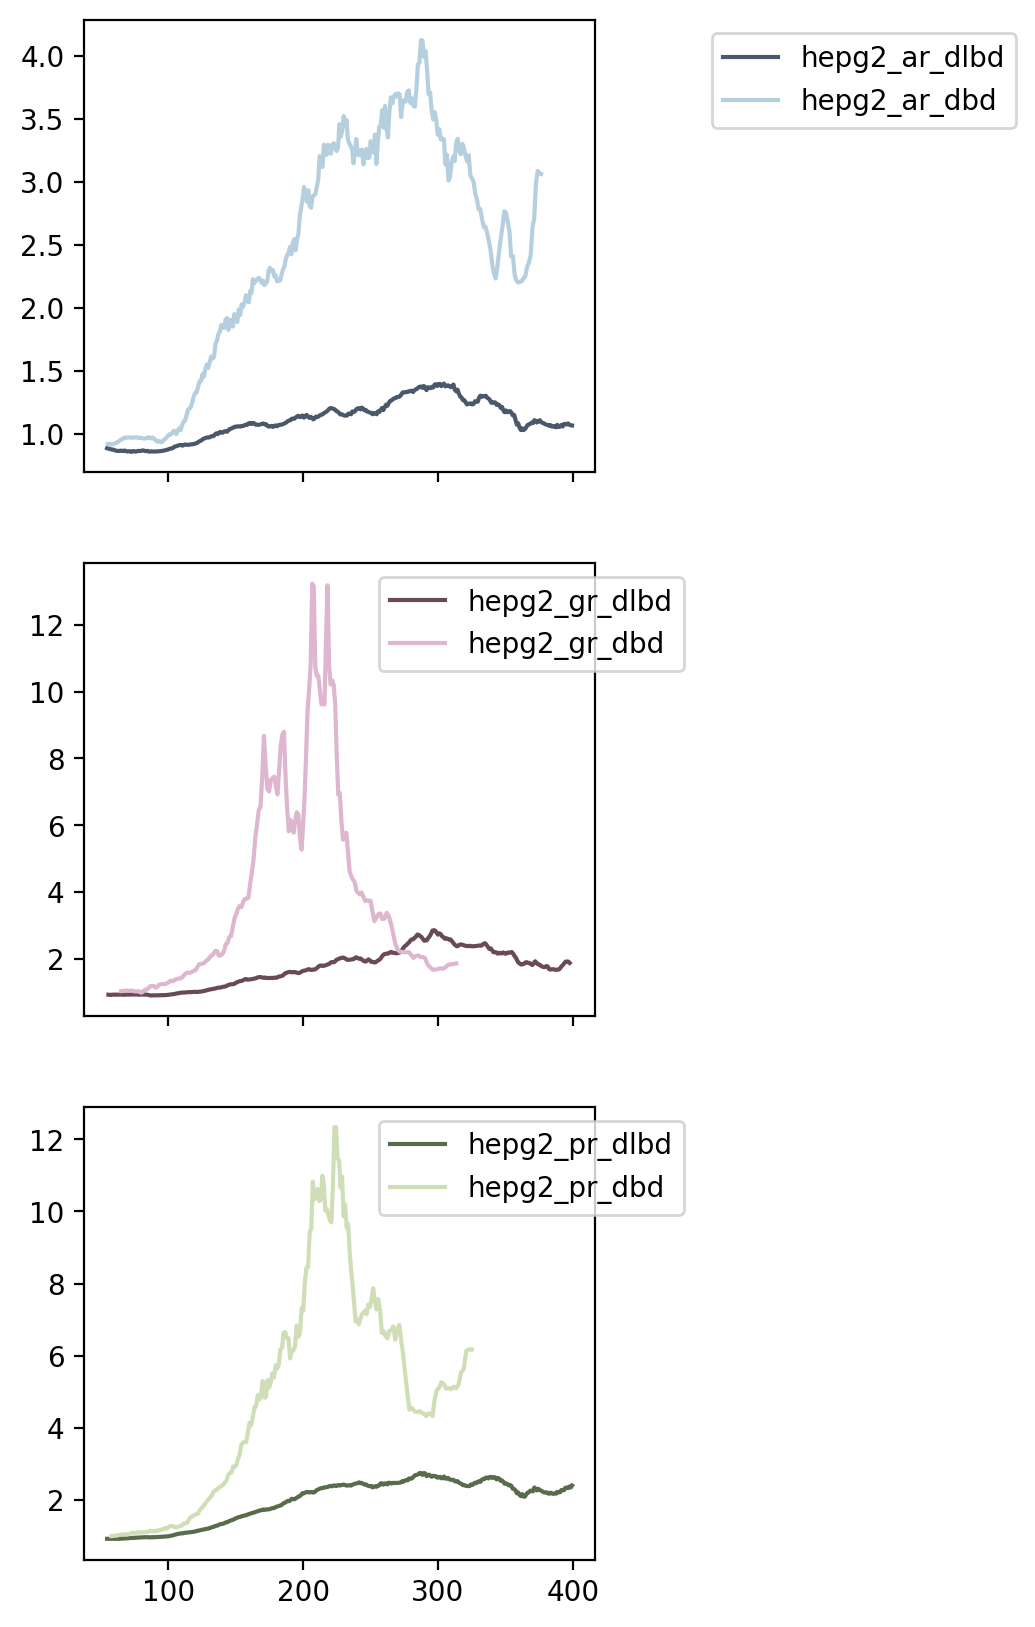

In [35]:



fig, axes = plt.subplots(3,1, sharex=True, figsize=(3.3,10))

ax=axes[0]
arhepg2 = process_hepg2('AR', ['hepg2_ar_dlbd', 'hepg2_ar_dbd'], [color_dict['AR']['dLBD'], color_dict['AR']['DBD']], ax)
ax.legend(bbox_to_anchor=[1.2,1])

ax=axes[1]
grhepg2 = process_hepg2('GR', ['hepg2_gr_dlbd', 'hepg2_gr_dbd'], [color_dict['GR']['dLBD'], color_dict['GR']['DBD']], ax)
ax.legend(bbox_to_anchor=[1.2,1])

ax = axes[2]
prhepg2 = process_hepg2('PR', ['hepg2_pr_dlbd', 'hepg2_pr_dbd'], [color_dict['PR']['dLBD'], color_dict['PR']['DBD']], ax)
ax.legend(bbox_to_anchor=[1.2,1])
fig.savefig('figures/interactions_hepg2.pdf')


/tmp/ipykernel_2061515/3841908783.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0–50', '0–50', '0–50', '0–50', '0–50', ..., '450–500', '450–500', NaN, NaN, NaN]
Length: 771
Categories (10, object): ['0–50' < '50–100' < '100–150' < '150–200' ... '300–350' < '350–400' < '400–450' < '450–500']' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  ap1_dlbd.loc[:, 'bins'] = binned.values
/tmp/ipykernel_2061515/3841908783.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mean = ap1_dlbd.drop('absdist', axis=1).groupby('bins').mean()
/tmp/ipykernel_2061515/3841908783.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of

Text(0.5, 1.0, 'HepG2 PR-DBD')

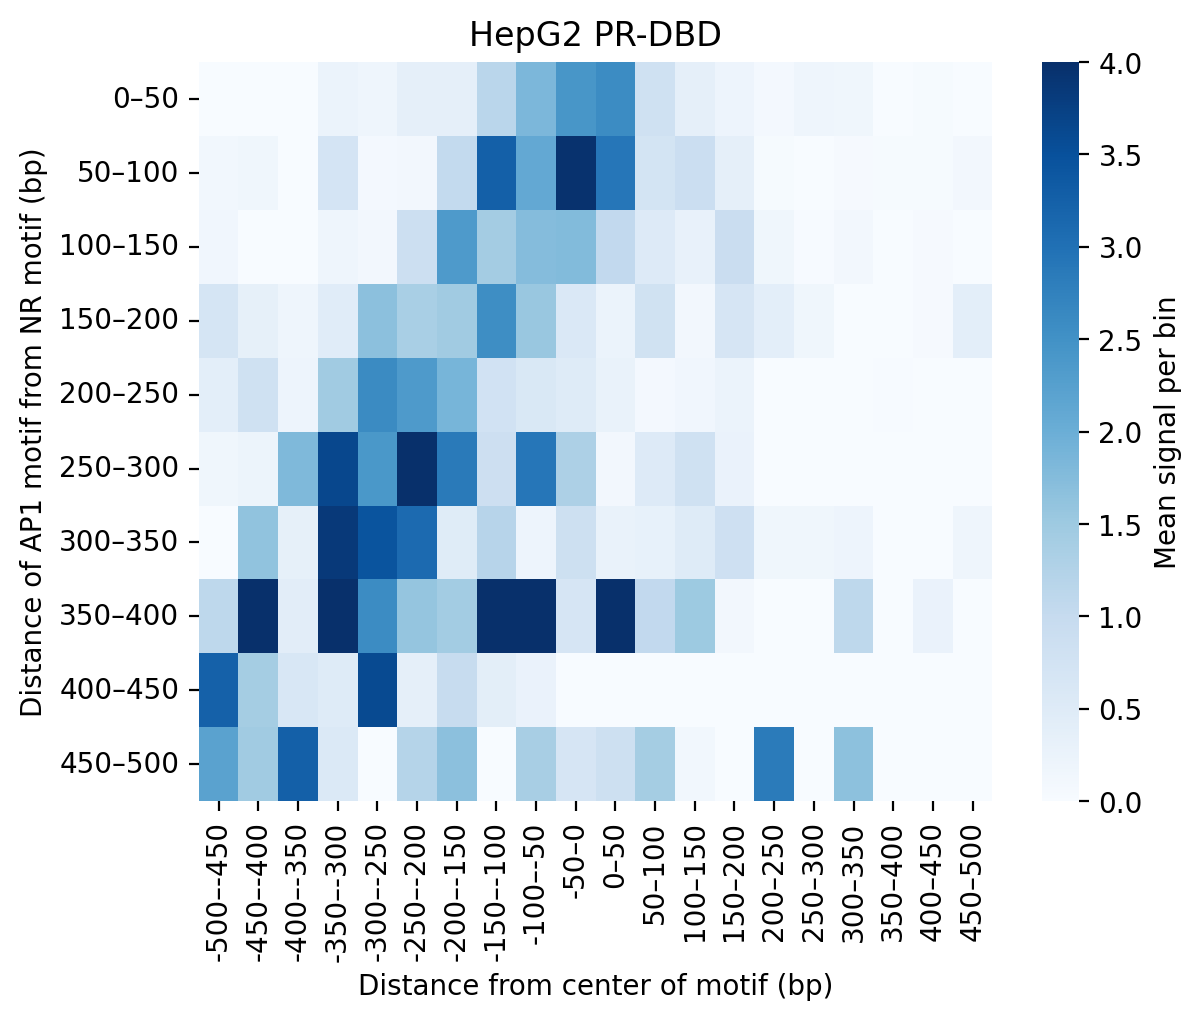

In [63]:


ap1_dlbd = prhepg2['hepg2_pr_dbd']['AP1']
bins = np.arange(0,550, 50)   # <100, 100–200, 200–300
labels = [f"{int(left)}–{int(right)}" for left, right in zip(bins[:-1], bins[1:])]

binned = pd.cut(ap1_dlbd.absdist, bins=bins, labels=labels)  # right=True by default: (a, b]
ap1_dlbd.loc[:, 'bins'] = binned.values
bin_mean = ap1_dlbd.drop('absdist', axis=1).groupby('bins').mean()
bin_mean.columns = bin_mean.columns - 500

# bins = [-np.inf, -400, -300, -200,-100, 100, 200, 300, 400, np.inf]
bins = np.arange(-500, 550, 50)
labels = [f"{int(left)}–{int(right)}" for left, right in zip(bins[:-1], bins[1:])]

col_bins = pd.cut(
    bin_mean.columns,
    labels=labels,
    bins=bins,
    right=False   # [0,100), [100,200), ...
)
bin_mean.columns = col_bins
fig, ax = plt.subplots(1)

sns.heatmap(bin_mean.T.reset_index().groupby('index').mean().T,
            cmap='Blues',ax=ax, cbar_kws = {'label':'Mean signal per bin'}, vmax=4)
ax.set_xlabel('Distance from center of motif (bp)')
ax.set_ylabel('Distance of AP1 motif from NR motif (bp)')
ax.set_title('HepG2 PR-DBD')
# fig.savefig('figures/newfig_prdlbd.pdf')

## 6H_2

In [ ]:
keys = ['nmumg_mar_dlbd', 'nmumg_ar_dlbd_dn100', 'nmumg_ar_dlbd_dn150', 'nmumg_ar_dlbd_dn200',
  'nmumg_mar_dlbd_dn300', 'nmumg_mar_dlbd_dn350', 'nmumg_mar_dlbd_dn400', 'nmumg_mar_dlbd_dn450', 'nmumg_mar_dbd',  ]
mlist = ['AP1']

# fig, ax = plt.subplots(1)
sig_dict = dict()
for i in keys:
    params, cpeak, lf = prep_peak_fimos(i, 'AR', metadata)
    mid_m, npeaks, cpyranges = calculate_motif_distances(f'data/combined_threshed_peaks_wsummits/output_fimo_fasta_{i}_fc10_AR_NR_mot/fimo.gff', 'AR_NR_mot', loaded_fimos=lf, peak= cpeak)
    cavbw = average_bgs(params.NormBG)
    cmd, cfps = extract_signals_with_dists(mid_m.filter(regex='Chromosome|NR_'),cavbw, mlist, cpyranges)
    sig_dict[i] = cfps



/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

AP1


/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

AP1


/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:160: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  empty_removed = df.groupby(["Chromosome", "Strand"])
join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python

...

/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:160: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  empty_removed = df.groupby(["Chromosome", "Strand"])
join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.
/home/labs/barkailab/vovam/.local/lib/python

AP1


/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

AP1


/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:160: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  empty_removed = df.groupby(["Chromosome", "Strand"])
join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.


/tmp/ipykernel_541638/3266133100.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(i, val, c=color,)
/tmp/ipykernel_541638/3266133100.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(i, val, c=color,)
/tmp/ipykernel_541638/3266133100.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length

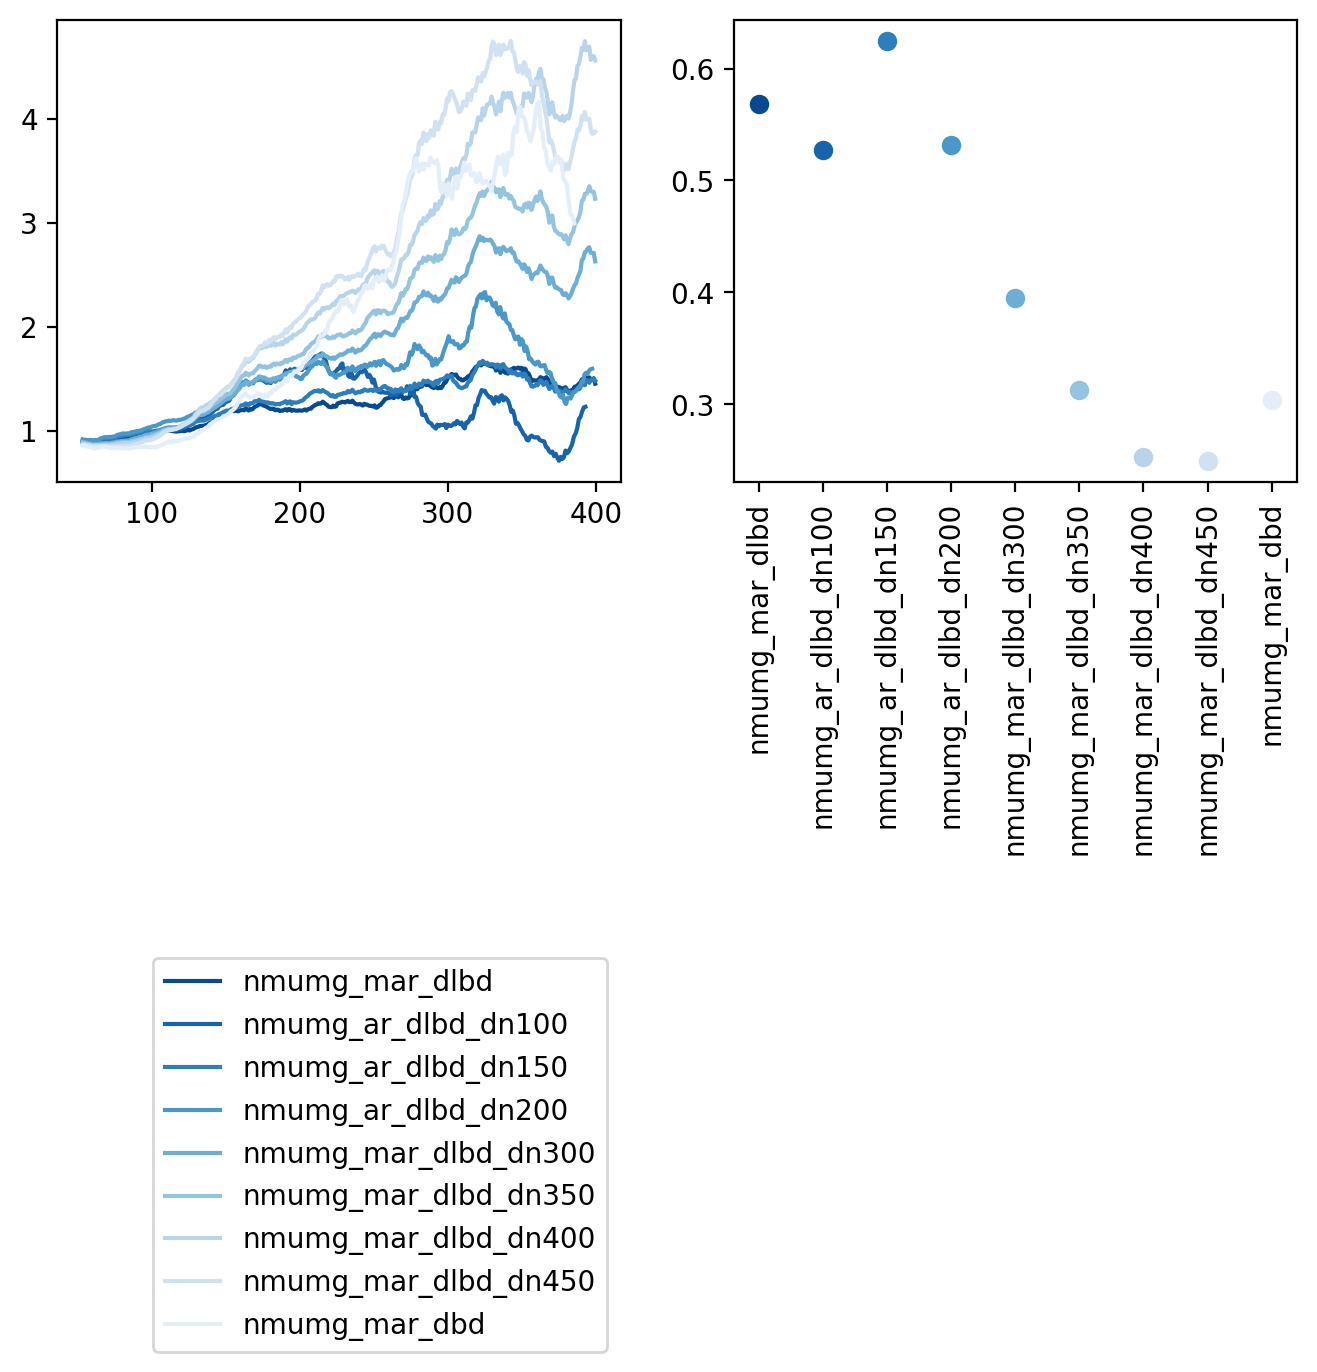

In [ ]:
fig, (ax,ax1) = plt.subplots(1,2, sharey=False, figsize=(8,3))
palette = sns.color_palette('Blues_r', n_colors=len(sig_dict))
rmsed = dict()
i=0
for (key, value), color in zip(sig_dict.items(), palette):
    sum_mid = value['AP1'].iloc[:, 450:550].mean(axis=1)
    t = pd.concat([sum_mid, value['AP1'].iloc[:, -1], value['AP1'].query("absdist<450").apply(lambda x: x[450-x['absdist']:550-x['absdist']].mean(), axis=1)], axis=1).dropna()
    smoothed = t.groupby('absdist').mean().reset_index().rolling(window=100, center=False).apply(lambda x: stats.trim_mean(x, 0.1)).dropna()
    val = smoothed.iloc[-100:,1].mean()/smoothed.iloc[:100,1].mean()

    ax.plot(smoothed.absdist, smoothed.iloc[:, 2]/smoothed.iloc[:, 1], label=key, c=color)
    ax1.scatter(i, val, c=color,)
    i+=1
ax1.set_xticks(np.arange(len(keys)), keys, rotation=90)
ax.legend(bbox_to_anchor=[1,-1])
fig.savefig('figures/Fig6/6H_2.pdf')

/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

AP1


/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

AP1


/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

...

/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:160: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  empty_removed = df.groupby(["Chromosome", "Strand"])
join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python

AP1


/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

AP1


/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:160: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  empty_removed = df.groupby(["Chromosome", "Strand"])
join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.
/tmp/ipykernel_541638/1358035573.py:25: User

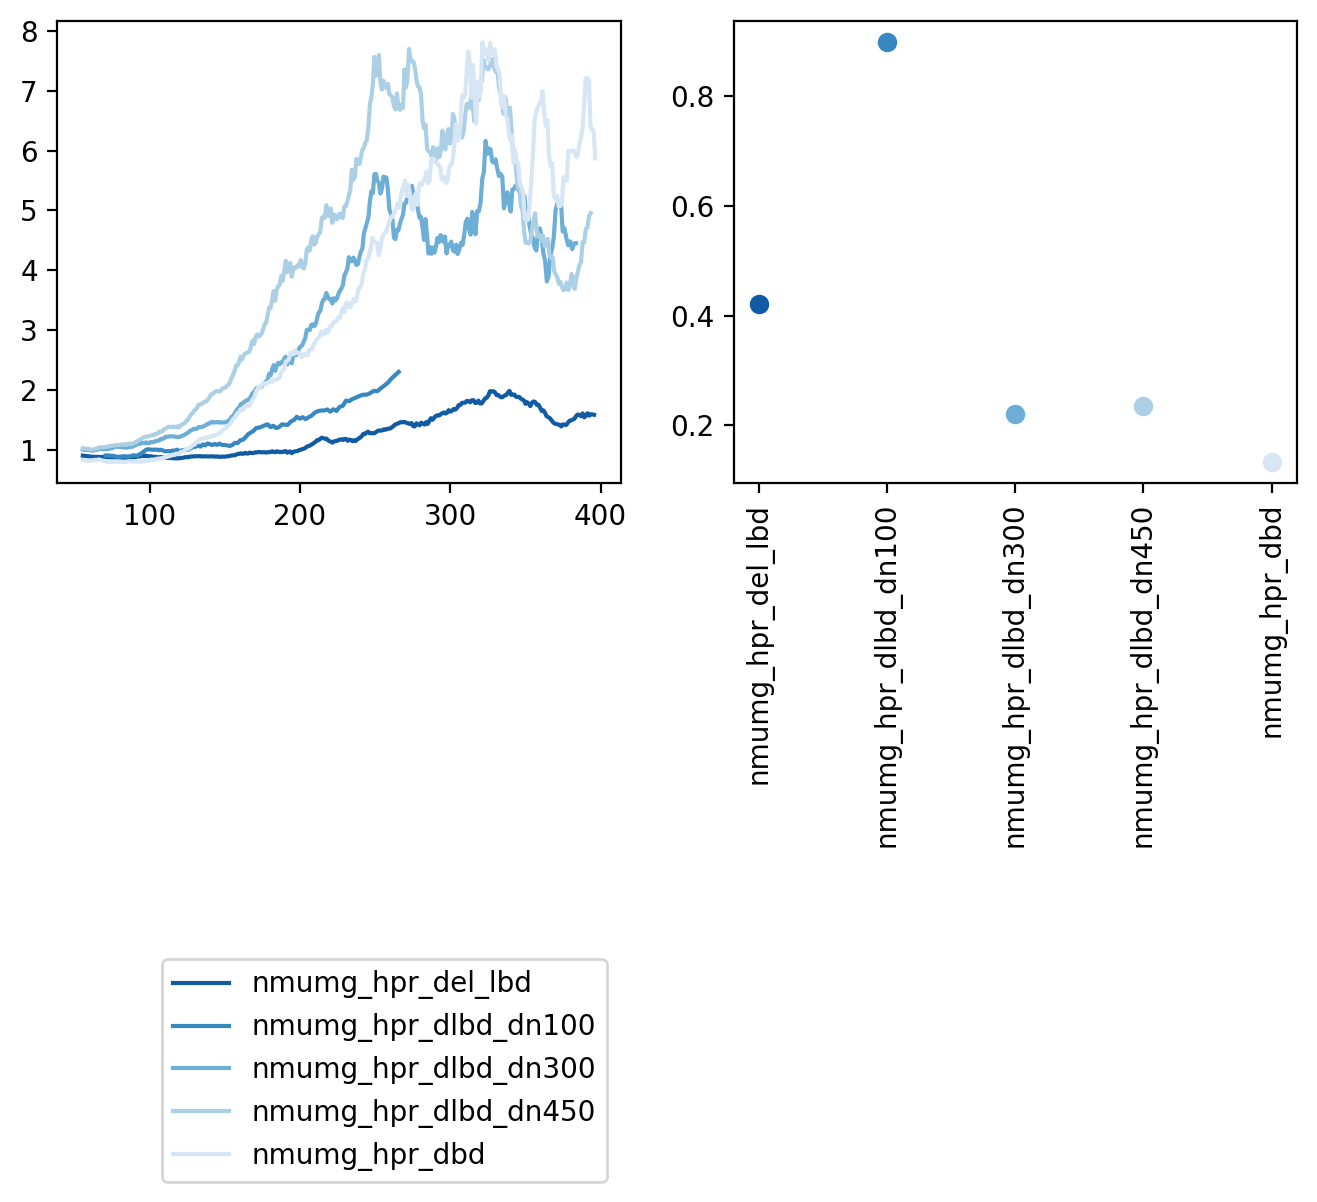

In [ ]:
keys = ['nmumg_hpr_del_lbd', 'nmumg_hpr_dlbd_dn100',
       'nmumg_hpr_dlbd_dn300', 'nmumg_hpr_dlbd_dn450', 'nmumg_hpr_dbd', ]
mlist = ['AP1']

# fig, ax = plt.subplots(1)
sig_dict = dict()
for i in keys:
    params, cpeak, lf = prep_peak_fimos(i, 'PR', metadata)
    mid_m, npeaks, cpyranges = calculate_motif_distances(f'data/combined_threshed_peaks_wsummits/output_fimo_fasta_{i}_fc10_PR_NR_mot/fimo.gff', 'PR_NR_mot', loaded_fimos=lf, peak= cpeak)
    cavbw = average_bgs(params.NormBG)

    cmd, cfps = extract_signals_with_dists(mid_m.filter(regex='Chromosome|NR_'),cavbw, mlist, cpyranges)
    sig_dict[i] = cfps
fig, (ax,ax1) = plt.subplots(1,2, sharey=False, figsize=(8,3))
palette = sns.color_palette('Blues_r', n_colors=len(sig_dict))
rmsed = dict()
i=0
for (key, value), color in zip(sig_dict.items(), palette):
    sum_mid = value['AP1'].iloc[:, 450:550].mean(axis=1)
    t = pd.concat([sum_mid, value['AP1'].iloc[:, -1], value['AP1'].query("absdist<450").apply(lambda x: x[450-x['absdist']:550-x['absdist']].mean(), axis=1)], axis=1).dropna()
    smoothed = t.groupby('absdist').mean().reset_index().rolling(window=100, center=False).apply(lambda x: stats.trim_mean(x, 0.1)).dropna()
    val = smoothed.iloc[-100:,1].mean()/smoothed.iloc[:100,1].mean()

    ax.plot(smoothed.absdist, smoothed.iloc[:, 2]/smoothed.iloc[:, 1], label=key, c=color)
    ax1.scatter(i, val, c=color,)
    i+=1
ax1.set_xticks(np.arange(len(keys)), keys, rotation=90)
ax.legend(bbox_to_anchor=[1,-1])
fig.savefig('figures/Supp/S9E_1.pdf')

/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

AP1


/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:160: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  empty_removed = df.groupby(["Chromosome", "Strand"])
join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.
/home/labs/barkailab/vovam/.local/lib/python

AP1


/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

...

/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

AP1


/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

AP1


/home/labs/barkailab/vovam/.local/lib/python3.10/site-packages/pyranges/methods/init.py:160: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  empty_removed = df.groupby(["Chromosome", "Strand"])
join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.
/tmp/ipykernel_541638/1867728515.py:29: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(i, val, c=color,)
/tmp/ipykernel_54163

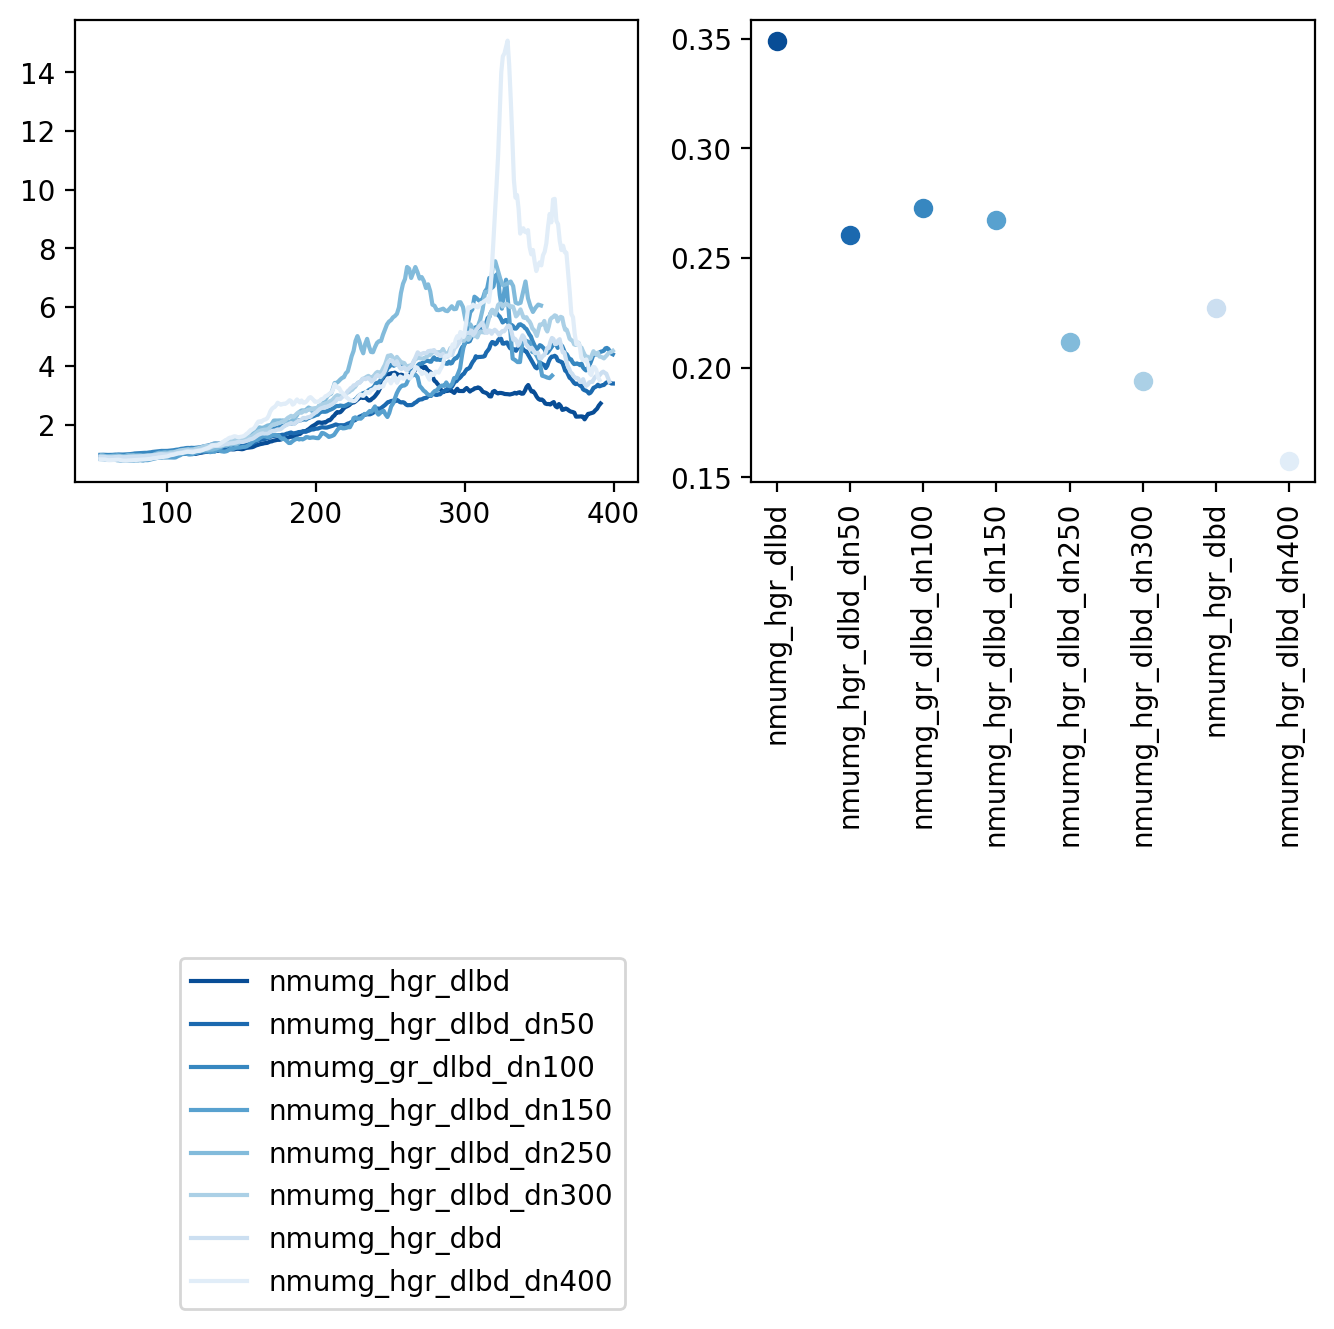

In [ ]:
keys =['nmumg_hgr_dlbd', 'nmumg_hgr_dlbd_dn50','nmumg_gr_dlbd_dn100', 
       'nmumg_hgr_dlbd_dn150', 'nmumg_hgr_dlbd_dn250', 'nmumg_hgr_dlbd_dn300',
       'nmumg_hgr_dbd', 'nmumg_hgr_dlbd_dn400']


mlist = ['AP1']

# fig, ax = plt.subplots(1)
sig_dict = dict()
for i in keys:
    params, cpeak, lf = prep_peak_fimos(i, 'GR', metadata)
    mid_m, npeaks, cpyranges = calculate_motif_distances(f'data/combined_threshed_peaks_wsummits/output_fimo_fasta_{i}_fc10_GR_NR_mot/fimo.gff', 'GR_NR_mot', loaded_fimos=lf, peak= cpeak)
    cavbw = average_bgs(params.NormBG)

    cmd, cfps = extract_signals_with_dists(mid_m.filter(regex='Chromosome|NR_'),cavbw, mlist, cpyranges)
    sig_dict[i] = cfps

fig, (ax,ax1) = plt.subplots(1,2, sharey=False, figsize=(8,3))
palette = sns.color_palette('Blues_r', n_colors=len(sig_dict))
rmsed = dict()
i=0
for (key, value), color in zip(sig_dict.items(), palette):
    sum_mid = value['AP1'].iloc[:, 450:550].mean(axis=1)
    t = pd.concat([sum_mid, value['AP1'].iloc[:, -1], value['AP1'].query("absdist<450").apply(lambda x: x[450-x['absdist']:550-x['absdist']].mean(), axis=1)], axis=1).dropna()
    smoothed = t.groupby('absdist').mean().reset_index().rolling(window=100, center=False).apply(lambda x: stats.trim_mean(x, 0.1)).dropna()
    val = smoothed.iloc[-100:,1].mean()/smoothed.iloc[:100,1].mean()

    ax.plot(smoothed.absdist, smoothed.iloc[:, 2]/smoothed.iloc[:, 1], label=key, c=color)
    ax1.scatter(i, val, c=color,)
    i+=1
ax1.set_xticks(np.arange(len(keys)), keys, rotation=90)
ax.legend(bbox_to_anchor=[1,-1])
fig.savefig('figures/Supp/S9E_2.pdf')